# Notebook Classification

In aceasta parte a temei, partea de clasificare va fi facuta pe un dataset cu meciuri de fotbal din Anglia. Contine mai multe meciuri, din mai multi ani, inclusiv anii 90'. Scopul e sa facem o clasificare, sa stim tipul de rezultat final dintre 2 echipe din Premier League.

Link-ul de unde se poate gasi acest dataset este : https://www.kaggle.com/datasets/panaaaaa/english-premier-league-and-championship-full-dataset/data?select=England+CSV.csv

- Contine mai multe date, cum ar fi : data, sezon, cartonare rosii, galbene, fault-uri, cornere, etc. . Totusi, pe unele dintre ele, cum ar fi nr de cartonase, nu avem cum sa le cunoastem de dinainte.
- O metoda de optimizare, este de ex. sa luam media faulturilor sau cartonaselor rosii. De exemplu, daca media cartonaselor rosii din ultimele 5 meciuri e mare atunci exista o tendinta sa piarda acel meci, deoarece exista o probabilitate mare sa ia echipa respectiva un cartonas rosu.
- Coloana pe care dorim sa o prezicem este : ***FT Result***

- **Totusi pentru rezultate mai bune, vom presupune ca ne aflam din perspectiva telespectatorului la pauza si avem acces la restul statisticilor de pana la pauza, iar pe baza lor dorim sa aflam rezultatul final.**

Coloane input : Date, Season, HomeTeam, AwayTeam, FTH Goals, FTA Goals, FT Result, HTH Goals, HTA Goals, HT Result, H Shots, A Shots, H SOT, A SOT, H Corners, A Corners, H Fouls, A Fouls, H Yellow, A Yellow, H Red, A Red, Referee, League, Display_Order

Astfel, in urma acestui notebook, vom afla top 5 modele de ML care prezic cel mai bun rezultat.
- **Coloana tinta (y)**:  — rezultatul final al meciului
- **Coloanele input (X)**: vor fi construite in etapa de feature engineering, pe baza statisticilor istorice ale echipelor

Nota personala: Am ales intentionat o tema mai putin conventionala — prezicerea rezultatelor din Premier League. Stiu ca o acuratete de 60% poate parea mica la prima vedere, insa fotbalul este unul dintre cele mai greu de prezis domenii din sport. Am vrut sa incerc ceva diferit si interesant.Chiar daca numerele nu sunt spectaculoase, procesul in sine — de la curatarea datelor, constructia statisticilor istorice, compararea a 9 algoritmi si analiza SHAP — reprezinta un flux complet si real de Machine Learning aplicat pe date din lumea reala.


In [153]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
%load_ext autoreload
%autoreload 2

df = pd.read_csv('../Datasets/England CSV.csv')
print(f'Shape: {df.shape}')

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Shape: (12153, 25)


#### Coloanele:

In [154]:
df.columns

Index(['Date', 'Season', 'HomeTeam', 'AwayTeam', 'FTH Goals', 'FTA Goals',
       'FT Result', 'HTH Goals', 'HTA Goals', 'HT Result', 'Referee',
       'H Shots', 'A Shots', 'H SOT', 'A SOT', 'H Fouls', 'A Fouls',
       'H Corners', 'A Corners', 'H Yellow', 'A Yellow', 'H Red', 'A Red',
       'Display_Order', 'League'],
      dtype='str')

#### Tipurile de date pentru fiecare coloana:
- putem observa ca unele tipuri de date au si null, deoarece nu sunt 12153, ci mai putine.

In [155]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 12153 entries, 0 to 12152
Data columns (total 25 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Date           12153 non-null  str    
 1   Season         12153 non-null  str    
 2   HomeTeam       12153 non-null  str    
 3   AwayTeam       12153 non-null  str    
 4   FTH Goals      12153 non-null  int64  
 5   FTA Goals      12153 non-null  int64  
 6   FT Result      12153 non-null  str    
 7   HTH Goals      11229 non-null  float64
 8   HTA Goals      11229 non-null  float64
 9   HT Result      11229 non-null  str    
 10  Referee        9329 non-null   str    
 11  H Shots        9329 non-null   float64
 12  A Shots        9329 non-null   float64
 13  H SOT          9329 non-null   float64
 14  A SOT          9329 non-null   float64
 15  H Fouls        9329 non-null   float64
 16  A Fouls        9329 non-null   float64
 17  H Corners      9329 non-null   float64
 18  A Corners      93

In [156]:
df.head()

,Date,Season,HomeTeam,AwayTeam,FTH Goals,FTA Goals,FT Result,HTH Goals,HTA Goals,HT Result,...,H Fouls,A Fouls,H Corners,A Corners,H Yellow,A Yellow,H Red,A Red,Display_Order,League
0,16/01/2025,2024/25,Ipswich Town,Brighton & Hove Albion,0,2,A,0.0,1.0,A,...,13.0,14.0,1.0,9.0,2.0,2.0,0.0,0.0,20250116,Premier League
1,16/01/2025,2024/25,Man United,Southampton,3,1,H,0.0,1.0,A,...,7.0,10.0,4.0,4.0,1.0,3.0,0.0,0.0,20250116,Premier League
2,15/01/2025,2024/25,Everton,Aston Villa,0,1,A,0.0,0.0,D,...,17.0,10.0,8.0,5.0,2.0,1.0,0.0,0.0,20250115,Premier League
3,15/01/2025,2024/25,Leicester,Crystal Palace,0,2,A,0.0,0.0,D,...,7.0,6.0,4.0,3.0,0.0,0.0,0.0,0.0,20250115,Premier League
4,15/01/2025,2024/25,Newcastle,Wolves,3,0,H,1.0,0.0,H,...,10.0,13.0,4.0,2.0,0.0,2.0,0.0,0.0,20250115,Premier League


### Analiza calitativa / curatarea datelor:
- se obs ca datele sunt null unde sunt meciuri de mult timp , ex din 96', cand nu se puteau colecta datele.
- in plus, pentru predictia actuala nu conteaza, nu are vreo importanta, deci vom elimina randurile acelea

In [157]:
df.isnull().sum()

Date                0
Season              0
HomeTeam            0
AwayTeam            0
FTH Goals           0
FTA Goals           0
FT Result           0
HTH Goals         924
HTA Goals         924
HT Result         924
Referee          2824
H Shots          2824
A Shots          2824
H SOT            2824
A SOT            2824
H Fouls          2824
A Fouls          2824
H Corners        2824
A Corners        2824
H Yellow         2824
A Yellow         2824
H Red            2824
A Red            2824
Display_Order       0
League              0
dtype: int64

In [158]:
df.dropna(inplace=True)
df.shape

(9329, 25)

#### Acum nu mai exista randuri cu valori null si ar fi toate date relevante

In [159]:
df.isnull().sum()

Date             0
Season           0
HomeTeam         0
AwayTeam         0
FTH Goals        0
FTA Goals        0
FT Result        0
HTH Goals        0
HTA Goals        0
HT Result        0
Referee          0
H Shots          0
A Shots          0
H SOT            0
A SOT            0
H Fouls          0
A Fouls          0
H Corners        0
A Corners        0
H Yellow         0
A Yellow         0
H Red            0
A Red            0
Display_Order    0
League           0
dtype: int64

### Acum vom renunta la coloanele care nu sunt folositoare, de exemplu: arbitrul, liga, display order , iar data o vom sterge la final.

In [160]:
df = df.drop(['Referee','League','Display_Order'],axis=1)
df.shape

(9329, 22)

# Analiza exploratorie

- dorim sa vedem cum sunt corelate datele, legaturile dintre coloane
- mai jos se vede ca echipa de acasa are o tendinta mai buna pe orice statistica, mai putin la fault uri
- deviatia standard de ajuta la goluri, deoarece datele nu sunt asa imprastiate

In [161]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
FTH Goals,9329.0,1.536178,1.305748,0.0,1.0,1.0,2.0,9.0
FTA Goals,9329.0,1.179333,1.157003,0.0,0.0,1.0,2.0,9.0
HTH Goals,9329.0,0.687641,0.835261,0.0,0.0,0.0,1.0,5.0
HTA Goals,9329.0,0.518491,0.734551,0.0,0.0,0.0,1.0,5.0
H Shots,9329.0,13.618716,5.349420,0.0,10.0,13.0,17.0,43.0
A Shots,9329.0,10.784543,4.678710,0.0,7.0,10.0,14.0,31.0
H SOT,9329.0,6.007503,3.275177,0.0,4.0,6.0,8.0,24.0
A SOT,9329.0,4.704684,2.757288,0.0,3.0,4.0,6.0,20.0
H Fouls,9329.0,11.303462,3.752442,0.0,9.0,11.0,14.0,33.0
A Fouls,9329.0,11.781113,3.931377,1.0,9.0,12.0,14.0,29.0


Asimetria este doar pozitiva pentru ca nu exista ca nr de goluri sa fie negative.

In [162]:
df.skew(numeric_only=True)

FTH Goals    0.975128
FTA Goals    1.076766
HTH Goals    1.217881
HTA Goals    1.481468
H Shots      0.642805
A Shots      0.655182
H SOT        0.823543
A SOT        0.873413
H Fouls      0.437434
A Fouls      0.406391
H Corners    0.615626
A Corners    0.737246
H Yellow     0.769340
A Yellow     0.623094
H Red        4.147739
A Red        3.337277
dtype: float64

Majoritatea echipelor de acasa castiga.Asta influenteaza mult, unde se joaca.

In [163]:
df["FT Result"].value_counts()

FT Result
H    4278
A    2738
D    2313
Name: count, dtype: int64

La pauza exista mai multe partide la un rezultat de egalitate.

In [164]:
df["HT Result"].value_counts()

HT Result
D    3818
H    3268
A    2243
Name: count, dtype: int64

Mai jos se pot observa urmatoarele :
- foarte rar conduce echipa de acasa la pauza si ea tot pierde. Adica daca away conduce la pauza, in maj cazurilor, mai bine de jumate, castiga si meciul.
- daca echipa de acasa castiga la pauza , are cele mai mari sanse sa castige meciul.
- cele mai multe sunt egaluri la pauza.
- cele mai multe victorii la final sunt la gazde.

In [165]:
pd.crosstab(df['HT Result'], df['FT Result'], margins=True)

FT Result,A,D,H,All
HT Result,,,,
A,1565,443,235,2243
D,994,1405,1419,3818
H,179,465,2624,3268
All,2738,2313,4278,9329


Grafic pentru rezultatul final, la fel ca la value_counts.

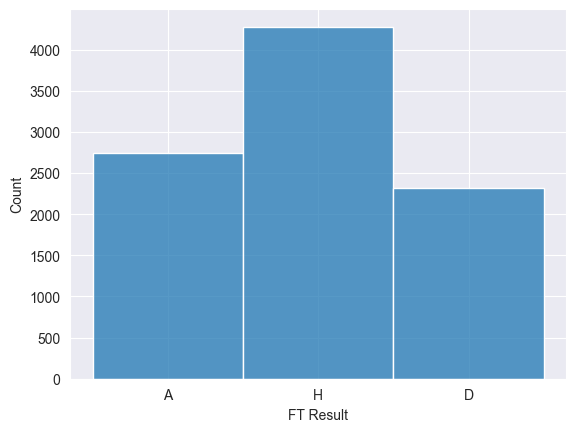

In [166]:
sns.histplot(data = df, x="FT Result")
plt.show()

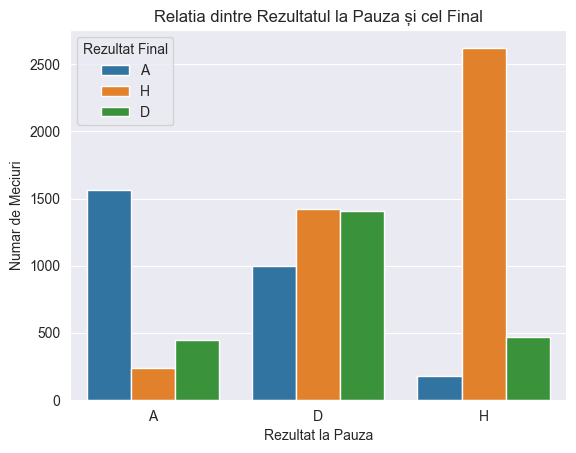

In [167]:
sns.countplot(data=df, x='HT Result', hue='FT Result')

plt.title('Relatia dintre Rezultatul la Pauza și cel Final')
plt.xlabel('Rezultat la Pauza')
plt.ylabel('Numar de Meciuri')
plt.legend(title='Rezultat Final')
plt.show()

Exista relatii intre :
- goluri si suturi
- suturi si cornere
- nr de suturi la pauza si final

<Axes: >

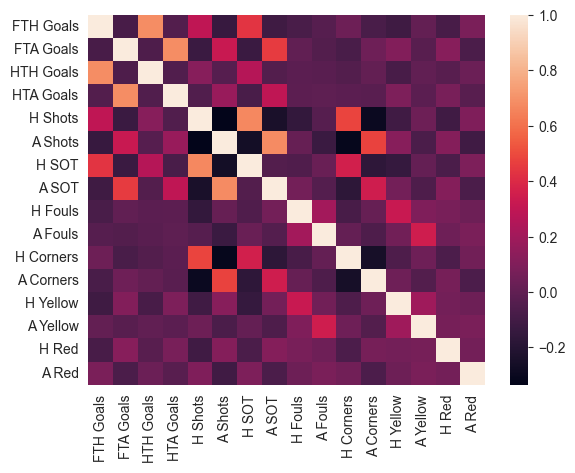

In [168]:
sns.heatmap(df.corr(numeric_only=True))

### Encodare :
- cu datele actuale nu ne putem da seama neaparat de relatii foarte specifice si vom encoda echipele, H,A,D

In [169]:
res_grid = {'H' : 0, 'D':1, 'A':2}
df['FT Result'] = df['FT Result'].str.strip()
df['HT Result'] = df['HT Result'].str.strip()
df['FT Result'] = df['FT Result'].map(res_grid)
df['HT Result'] = df['HT Result'].map(res_grid)


In [170]:
df.head(7)

,Date,Season,HomeTeam,AwayTeam,FTH Goals,FTA Goals,FT Result,HTH Goals,HTA Goals,HT Result,...,H SOT,A SOT,H Fouls,A Fouls,H Corners,A Corners,H Yellow,A Yellow,H Red,A Red
0,16/01/2025,2024/25,Ipswich Town,Brighton & Hove Albion,0,2,2,0.0,1.0,2,...,3.0,5.0,13.0,14.0,1.0,9.0,2.0,2.0,0.0,0.0
1,16/01/2025,2024/25,Man United,Southampton,3,1,0,0.0,1.0,2,...,9.0,5.0,7.0,10.0,4.0,4.0,1.0,3.0,0.0,0.0
2,15/01/2025,2024/25,Everton,Aston Villa,0,1,2,0.0,0.0,1,...,3.0,3.0,17.0,10.0,8.0,5.0,2.0,1.0,0.0,0.0
3,15/01/2025,2024/25,Leicester,Crystal Palace,0,2,2,0.0,0.0,1,...,4.0,4.0,7.0,6.0,4.0,3.0,0.0,0.0,0.0,0.0
4,15/01/2025,2024/25,Newcastle,Wolves,3,0,0,1.0,0.0,0,...,5.0,7.0,10.0,13.0,4.0,2.0,0.0,2.0,0.0,0.0
5,15/01/2025,2024/25,Arsenal,Tottenham,2,1,0,2.0,1.0,0,...,4.0,2.0,16.0,9.0,10.0,4.0,3.0,1.0,0.0,0.0
6,14/01/2025,2024/25,Brentford,Man City,2,2,1,0.0,0.0,1,...,6.0,8.0,4.0,4.0,4.0,5.0,0.0,0.0,0.0,0.0


- pentru a codifica corect echipele si pt a avea acelasi cod si la home si la away facem un dictionar prin reuniune si apoi codificam tot

In [171]:
common_set = set(df['HomeTeam']).union(set(df['AwayTeam']))
print(common_set)

{'Stoke', 'Arsenal', 'Blackpool', 'Newcastle', 'Sheffield United', 'Southampton', 'Charlton', 'Wigan', 'Birmingham', 'Fulham', 'Tottenham', 'Chelsea', 'Everton', 'Swansea', 'Luton', 'Man City', 'Leicester', 'Bradford', 'Derby', 'Reading', 'Hull', 'Crystal Palace', 'Brighton', 'Cardiff', 'Coventry', 'QPR', 'Bolton', 'Watford', 'West Brom', 'Aston Villa', 'Sunderland', 'Blackburn', 'West Ham', 'Burnley', "Nott'm Forest", 'Portsmouth', 'Leeds', 'Man United', 'Bournemouth', 'Liverpool', 'Ipswich Town', 'Ipswich', 'Middlesbrough', 'Wolves', 'Huddersfield', 'Brentford', 'Norwich', 'Brighton & Hove Albion'}


In [172]:
sorted_teams = sorted(list(common_set))
team_grid = {team:i for i, team in enumerate(sorted_teams)}
print(team_grid)

{'Arsenal': 0, 'Aston Villa': 1, 'Birmingham': 2, 'Blackburn': 3, 'Blackpool': 4, 'Bolton': 5, 'Bournemouth': 6, 'Bradford': 7, 'Brentford': 8, 'Brighton': 9, 'Brighton & Hove Albion': 10, 'Burnley': 11, 'Cardiff': 12, 'Charlton': 13, 'Chelsea': 14, 'Coventry': 15, 'Crystal Palace': 16, 'Derby': 17, 'Everton': 18, 'Fulham': 19, 'Huddersfield': 20, 'Hull': 21, 'Ipswich': 22, 'Ipswich Town': 23, 'Leeds': 24, 'Leicester': 25, 'Liverpool': 26, 'Luton': 27, 'Man City': 28, 'Man United': 29, 'Middlesbrough': 30, 'Newcastle': 31, 'Norwich': 32, "Nott'm Forest": 33, 'Portsmouth': 34, 'QPR': 35, 'Reading': 36, 'Sheffield United': 37, 'Southampton': 38, 'Stoke': 39, 'Sunderland': 40, 'Swansea': 41, 'Tottenham': 42, 'Watford': 43, 'West Brom': 44, 'West Ham': 45, 'Wigan': 46, 'Wolves': 47}


In [173]:
df["HomeTeam"] = df['HomeTeam'].astype(str).str.strip()
df["AwayTeam"] = df['AwayTeam'].astype(str).str.strip()
df['HomeTeam'] = df['HomeTeam'].map(team_grid)
df['AwayTeam'] = df['AwayTeam'].map(team_grid)

In [174]:
df.head(7)

,Date,Season,HomeTeam,AwayTeam,FTH Goals,FTA Goals,FT Result,HTH Goals,HTA Goals,HT Result,...,H SOT,A SOT,H Fouls,A Fouls,H Corners,A Corners,H Yellow,A Yellow,H Red,A Red
0,16/01/2025,2024/25,23,10,0,2,2,0.0,1.0,2,...,3.0,5.0,13.0,14.0,1.0,9.0,2.0,2.0,0.0,0.0
1,16/01/2025,2024/25,29,38,3,1,0,0.0,1.0,2,...,9.0,5.0,7.0,10.0,4.0,4.0,1.0,3.0,0.0,0.0
2,15/01/2025,2024/25,18,1,0,1,2,0.0,0.0,1,...,3.0,3.0,17.0,10.0,8.0,5.0,2.0,1.0,0.0,0.0
3,15/01/2025,2024/25,25,16,0,2,2,0.0,0.0,1,...,4.0,4.0,7.0,6.0,4.0,3.0,0.0,0.0,0.0,0.0
4,15/01/2025,2024/25,31,47,3,0,0,1.0,0.0,0,...,5.0,7.0,10.0,13.0,4.0,2.0,0.0,2.0,0.0,0.0
5,15/01/2025,2024/25,0,42,2,1,0,2.0,1.0,0,...,4.0,2.0,16.0,9.0,10.0,4.0,3.0,1.0,0.0,0.0
6,14/01/2025,2024/25,8,28,2,2,1,0.0,0.0,1,...,6.0,8.0,4.0,4.0,4.0,5.0,0.0,0.0,0.0,0.0


### Stergem coloanele de date brute:

Dorim sa eliminam numarul de goluri pentru a nu ajunge modelul nostru in cazul de overfitting, memorand sau invatand un pattern.

In [175]:
df = df.drop(columns=['Date', 'Season', 'FTH Goals', 'FTA Goals'])

Cum arata noul tabel:

In [176]:
df.head(5)

,HomeTeam,AwayTeam,FT Result,HTH Goals,HTA Goals,HT Result,H Shots,A Shots,H SOT,A SOT,H Fouls,A Fouls,H Corners,A Corners,H Yellow,A Yellow,H Red,A Red
0,23,10,2,0.0,1.0,2,5.0,11.0,3.0,5.0,13.0,14.0,1.0,9.0,2.0,2.0,0.0,0.0
1,29,38,0,0.0,1.0,2,23.0,13.0,9.0,5.0,7.0,10.0,4.0,4.0,1.0,3.0,0.0,0.0
2,18,1,2,0.0,0.0,1,10.0,11.0,3.0,3.0,17.0,10.0,8.0,5.0,2.0,1.0,0.0,0.0
3,25,16,2,0.0,0.0,1,21.0,9.0,4.0,4.0,7.0,6.0,4.0,3.0,0.0,0.0,0.0,0.0
4,31,47,0,1.0,0.0,0,17.0,13.0,5.0,7.0,10.0,13.0,4.0,2.0,0.0,2.0,0.0,0.0


Acum avem 15 coloane, cu datele din trecut si putem prezice pe baza acestor statistici.

In [177]:
df.shape

(9329, 18)

# ANALIZA EXPLORATORIE A DATELOR: ETAPA 2
In aceasta etapa urmarim din nou analiza exploratorie a datelor, dar pe noile statistici, fara cele eliminate.
- dorim sa vedem corelari intre diferite atribute pentru a putea creea un model de ML compact.
- este de asteptat ca rezultatele sa nu fie foarte bune, speram ca nici foarte rele, deoarece fotbalul este mai imprevizibil si depinde de mult mai multi factori externi. Totusi, vom incerca pe baza datelor gasite, statistici cat de cat valide.
- reamintim ca clasificarea, rezultatul pe care dorim sa il prezicem, este rezultatul final, adica coloana de *** FT Result***.(ea va fi vectorul y, iar restul matricea X).

<Axes: >

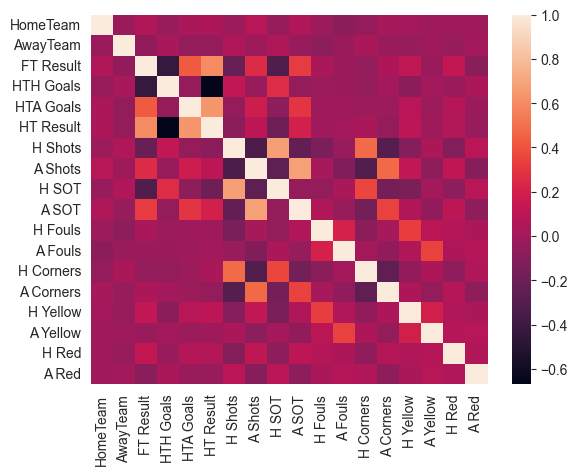

In [178]:
sns.heatmap(df.corr(numeric_only=True))


Deocamdata se observa rezultate intre :
- rezultatul final si cel de la pauza
- goluri pentru echipa gazda si rezultatul final
- cartonase galbele cu fault-uri
- cornerele pentru echipa de acasa au o relatie stransa cu suturile pe poarta

Mai departe vom face grafice cu noile rezultate calculate sa vedem cum este distributia lor in functie de rezultatul final.

### Grafice cu media golurilor in functie de rezultatul final.

Ce se poate observa din informatiile datelor de pana acum:
- FT Result e aproape de 1(Draw) si de 0(castiga echipa gazda).
Deci multe meciuri, o mare majoritate, au rezultatul final in favoarea egalului sau a echipei de acasa.
- cartonasele rosii nu ne ajuta(media), fiind destul de rare

In [179]:
df.describe()

,HomeTeam,AwayTeam,FT Result,HTH Goals,HTA Goals,HT Result,H Shots,A Shots,H SOT,A SOT,H Fouls,A Fouls,H Corners,A Corners,H Yellow,A Yellow,H Red,A Red
count,9329.000000,9329.000000,9329.000000,9329.000000,9329.000000,9329.000000,9329.000000,9329.000000,9329.000000,9329.000000,9329.000000,9329.000000,9329.000000,9329.000000,9329.000000,9329.000000,9329.000000,9329.000000
mean,24.654840,24.654733,0.834923,0.687641,0.518491,0.890128,13.618716,10.784543,6.007503,4.704684,11.303462,11.781113,6.056383,4.770715,1.462536,1.785722,0.062386,0.085968
std,14.411834,14.413427,0.851405,0.835261,0.734551,0.760742,5.349420,4.678710,3.275177,2.757288,3.752442,3.931377,3.107327,2.746754,1.215747,1.285168,0.252706,0.291579
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,14.000000,14.000000,0.000000,0.000000,0.000000,0.000000,10.000000,7.000000,4.000000,3.000000,9.000000,9.000000,4.000000,3.000000,1.000000,1.000000,0.000000,0.000000
50%,26.000000,26.000000,1.000000,0.000000,0.000000,1.000000,13.000000,10.000000,6.000000,4.000000,11.000000,12.000000,6.000000,4.000000,1.000000,2.000000,0.000000,0.000000
75%,38.000000,38.000000,2.000000,1.000000,1.000000,1.000000,17.000000,14.000000,8.000000,6.000000,14.000000,14.000000,8.000000,6.000000,2.000000,3.000000,0.000000,0.000000
max,47.000000,47.000000,2.000000,5.000000,5.000000,2.000000,43.000000,31.000000,24.000000,20.000000,33.000000,29.000000,20.000000,19.000000,7.000000,9.000000,3.000000,2.000000


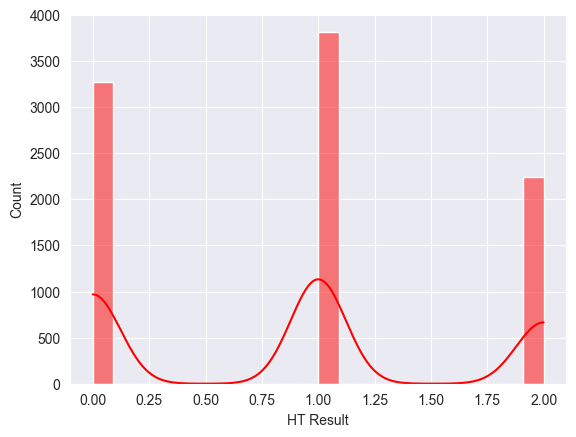

In [180]:
sns.histplot(data=df, x='HT Result',kde=True, color='red')
plt.show()

In graficul de mai sus putem observa ca cele mai multe meciuri au la pauza un rezultat de egalitate.

In graficul de mai jos putem observa ca media este aproape asemanatoare la inscrierea golurile de ambele tipuri de echipe pana la pauza.

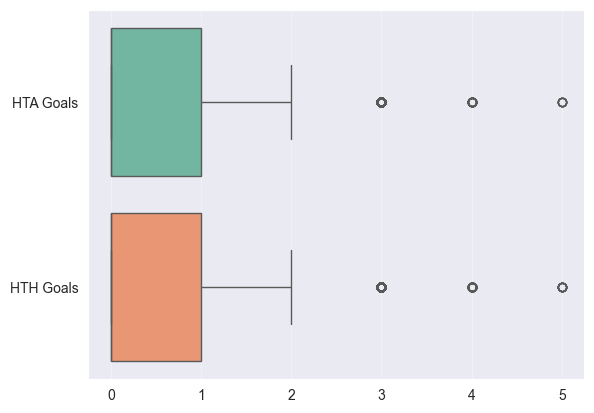

In [181]:
sns.boxplot(data=df[['HTA Goals', 'HTH Goals']], orient='h', palette='Set2')
plt.grid(axis='x', alpha=0.3)
plt.show()

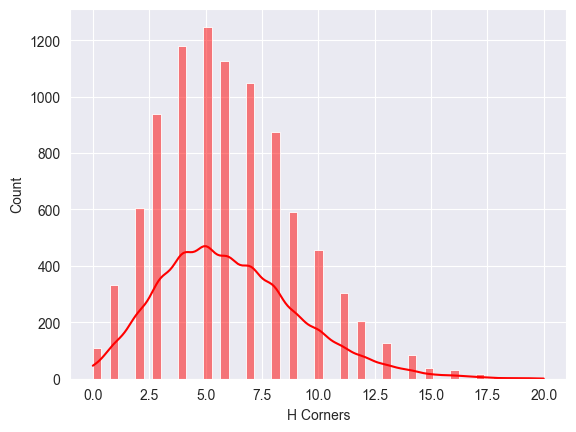

In [182]:
sns.histplot(data=df, x='H Corners',kde=True, color='red')
plt.show()

In graficul anterior se poate observa distributia corner-elor de la pauza. Aceasta are forma clopotului lui gauss, cu media in jurul valorii de 5.0 .

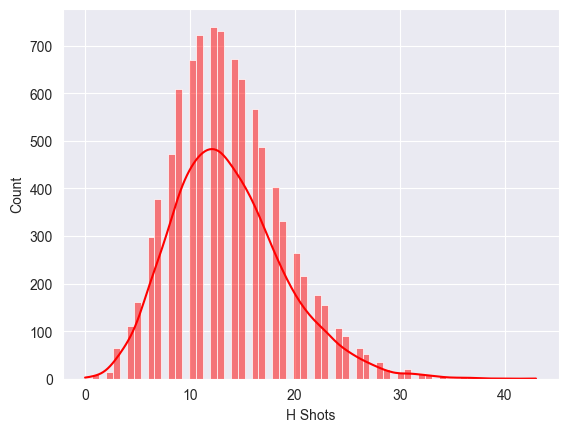

In [183]:
sns.histplot(data=df, x='H Shots',kde=True, color='red')
plt.show()

Asemenea, distributia suturilor echipei gazda are o forma gaussiana, cu varful boltei si mai mare.

### In urmatoarea parte dorim sa vede numeric, cat de strans sunt legate datele, prin coeficienti:

Cea mai puternica legatura cu rezultatul o are diferenta golurilor primite
- mai este si away avarage points

In [184]:
df.corr(numeric_only=True)

,HomeTeam,AwayTeam,FT Result,HTH Goals,HTA Goals,HT Result,H Shots,A Shots,H SOT,A SOT,H Fouls,A Fouls,H Corners,A Corners,H Yellow,A Yellow,H Red,A Red
HomeTeam,1.000000,-0.027025,0.053893,-0.033778,0.039216,0.044913,-0.019865,0.082620,-0.038762,0.054347,-0.022727,-0.082186,-0.050136,0.017645,0.011829,-0.014632,-0.008775,-0.010668
AwayTeam,-0.027025,1.000000,-0.062634,0.025805,-0.051914,-0.047525,0.059000,-0.017382,0.048288,-0.039176,-0.069990,-0.024385,0.030142,-0.035680,-0.040110,-0.015129,-0.031377,0.003977
FT Result,0.053893,-0.062634,1.000000,-0.431447,0.423481,0.596814,-0.223309,0.255698,-0.321149,0.320768,0.033801,-0.028604,-0.055643,0.046295,0.120379,-0.029097,0.131080,-0.092676
HTH Goals,-0.033778,0.025805,-0.431447,1.000000,-0.048246,-0.669824,0.122602,-0.034039,0.261458,-0.046528,-0.019623,-0.024382,-0.045836,0.006816,-0.080569,0.002955,-0.030071,0.031919
HTA Goals,0.039216,-0.051914,0.423481,-0.048246,1.000000,0.639317,-0.049974,0.176404,-0.075811,0.293365,-0.015551,-0.007879,-0.019761,-0.023057,0.088919,-0.018912,0.072329,-0.026943
HT Result,0.044913,-0.047525,0.596814,-0.669824,0.639317,1.000000,-0.082739,0.111628,-0.201551,0.197805,-0.010814,0.014827,0.038312,-0.044687,0.101783,-0.006320,0.066887,-0.035224
H Shots,-0.019865,0.059000,-0.223309,0.122602,-0.049974,-0.082739,1.000000,-0.334249,0.670453,-0.242373,-0.153743,-0.033902,0.482868,-0.294186,-0.106004,0.037281,-0.109604,0.095521
A Shots,0.082620,-0.017382,0.255698,-0.034039,0.176404,0.111628,-0.334249,1.000000,-0.263001,0.680280,0.016029,-0.128065,-0.316980,0.476892,0.121916,-0.072719,0.113738,-0.107596
H SOT,-0.038762,0.048288,-0.321149,0.261458,-0.075811,-0.201551,0.670453,-0.263001,1.000000,-0.045494,-0.055018,0.030068,0.355120,-0.171541,-0.142840,0.009780,-0.071287,0.089805
A SOT,0.054347,-0.039176,0.320768,-0.046528,0.293365,0.197805,-0.242373,0.680280,-0.045494,1.000000,0.060376,-0.041537,-0.177435,0.343603,0.057222,-0.058247,0.109526,-0.069760


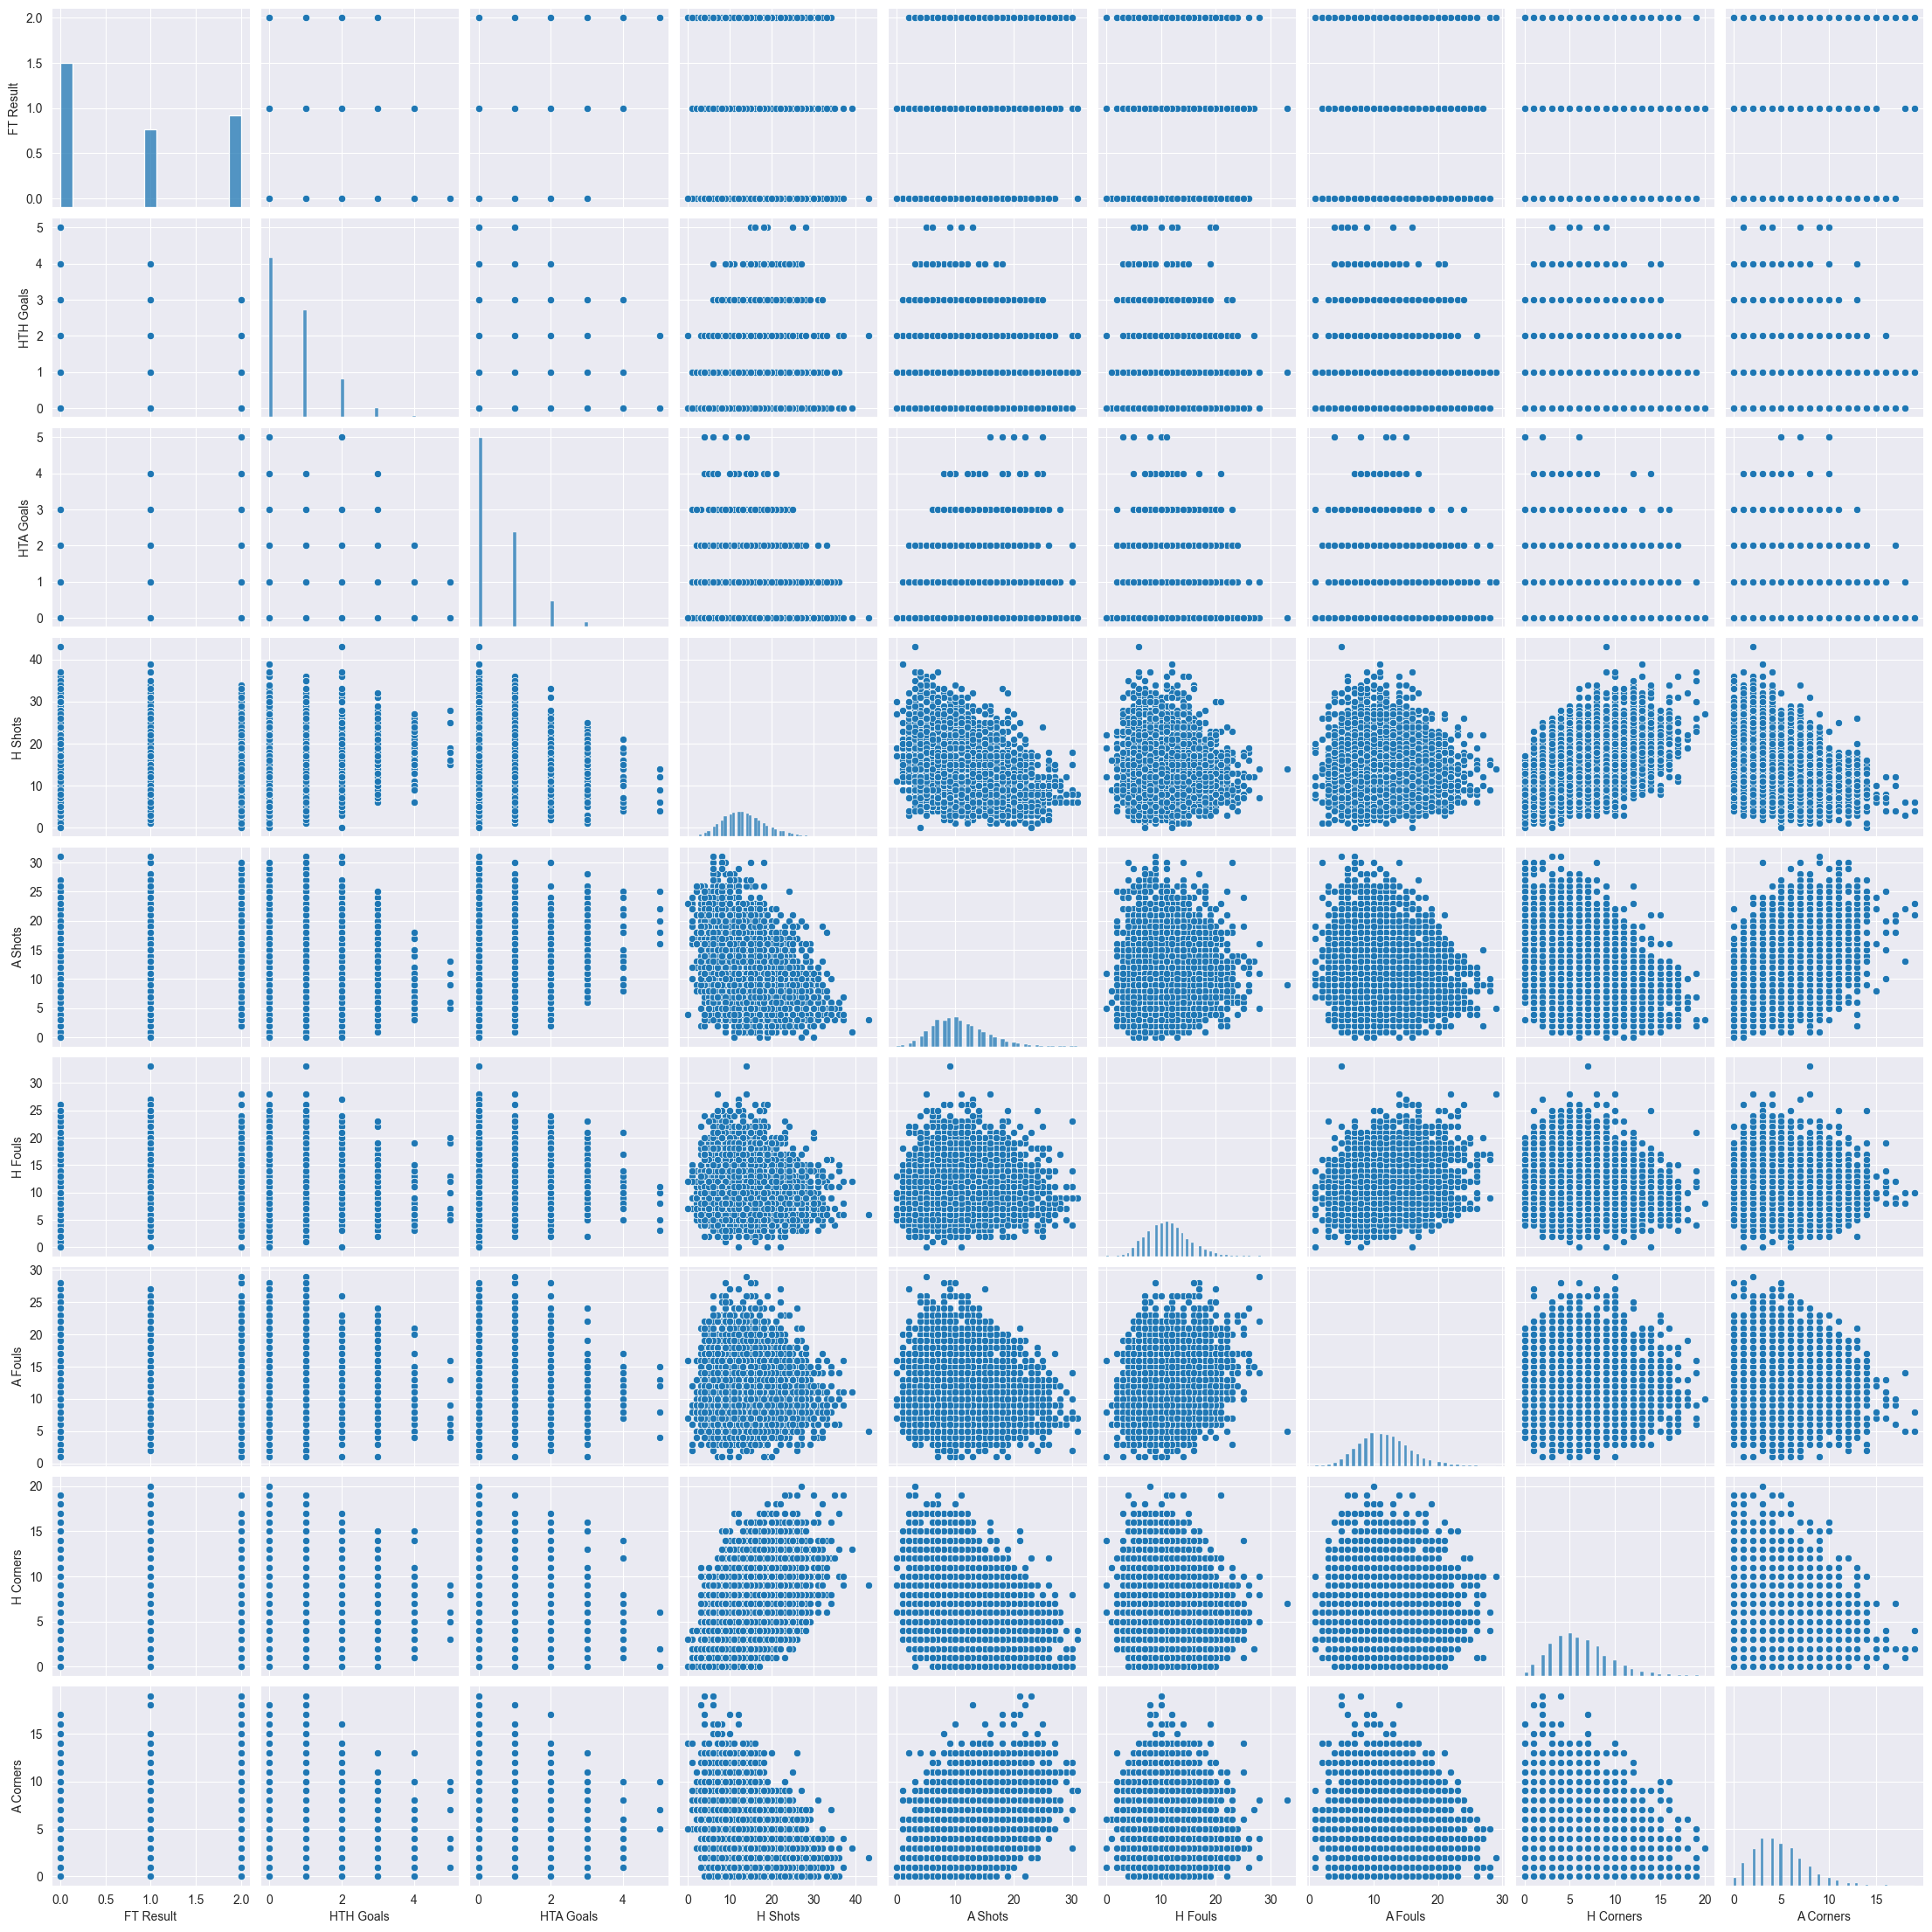

In [185]:
sns.pairplot(df[['FT Result','HTH Goals', 'HTA Goals', 'H Shots', 'A Shots', 'H Fouls', 'A Fouls', 'H Corners', 'A Corners']])

In graficele de mai sus se pot observa urmatoarele :
- relatia dintre cornere si suturi pare a fi una putin liniara, deoarece majoritatea exemplelor din aceste grafice tind sa aiba aceeasi directie.
- Restul statisticlor, care sunt grupate doar pe linii, deoarece nu sunt niste valori continue(cu o diferenta mica intre numere) sau nu exista o regula si ocupa tot spatiu de cautari cu mici zgomote.

# Etapa de analiza a algoritmilor de clasificare
Un urmatoarea parte a notebook-ului se vor rula pe rand fiecare algoritm de clasificare din cerita, iar pe parcurs, la fiecare se va face analiza pe precizie,acuratete, recall, f1_score, dar si se va trasa si explica curba de invatare
In plus, se vor analiza rezultatele cu biblioteca ***SHAP*** si se vor ajusta hiperparametrii pentru a ajunge la rezultate mai bune, insa vor avea grija la overfitting.

## 1. Naïve Bayes
Scurta descriere: Se foloseste formula lui Bayes intr-o retea de tip bayes, unde exista mai multe noduri care sunt dependente intre ele.
Una dintre cele mai bune solutii este dupa formula lui Gauss, unde se urmaresste acea distributie sub forma unui clopot, avand formula :
$$P(x_i | y) = \frac{1}{\sqrt{2\pi\sigma_y^2}} \exp\left(-\frac{(x_i - \mu_y)^2}{2\sigma_y^2}\right)$$

- iar formula lui Bayes este : $$P(H | E) = \frac{P(E | H) \cdot P(H)}{P(E)}$$

**Nota**: In cazul nostru, vom folosi modelul gaussian, deoarece lucram pe date de tip numere.
- mai exista si multinomial care este pentru cuvinte(frecventa lor) sau Bernoulli care lucreaza doar cu valori binare.

*Hiperparamterii*:
- var_smoothing : pt a netezi curba, pentru stabilitatea calculelor - valoarea default = 1e-9.
- priors : influenteaza probabilitatile ( nu il folosim )

In [186]:
df.to_csv('../Datasets/Football.csv')

### 1.1 Naive Bayes cu parametrii default

In [187]:
from sklearn.preprocessing import StandardScaler

y = df['FT Result']
X = df.drop('FT Result',axis=1)
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.25, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [188]:
import joblib
joblib.dump(scaler, '../Models/Classification/scaler.pkl')

['../Models/Classification/scaler.pkl']

              precision    recall  f1-score   support

           0       0.71      0.78      0.74      1047
           1       0.36      0.28      0.31       584
           2       0.62      0.65      0.63       702

    accuracy                           0.61      2333
   macro avg       0.56      0.57      0.56      2333
weighted avg       0.60      0.61      0.60      2333



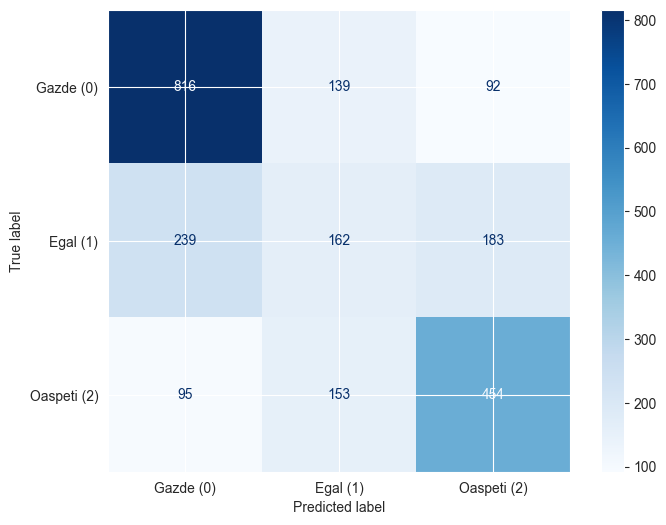

Total Accuracy: 0.61
Total precision : 0.60
Total Recall : 0.61
Total f1-score : 0.60
Total roc_auc : 0.79


In [189]:
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score, roc_auc_score, confusion_matrix,classification_report, ConfusionMatrixDisplay

naive_ml = GaussianNB()

naive_ml.fit(X_train_scaled, y_train)
y_pred_Bayes =naive_ml.predict(X_test_scaled)
y_probs_Bayes = naive_ml.predict_proba(X_test_scaled)
print(classification_report(y_true=y_test, y_pred = y_pred_Bayes))

acc_bayes = accuracy_score(y_test, y_pred_Bayes)
prec_bayes = precision_score(y_test, y_pred_Bayes, average='weighted')
rec_bayes = recall_score(y_test, y_pred_Bayes, average='weighted')
f1_bayes = f1_score(y_test, y_pred_Bayes, average='weighted')
roc_auc_bayes = roc_auc_score(y_test, y_probs_Bayes, multi_class='ovr', average='weighted')

cm_bayes = confusion_matrix(y_test, y_pred_Bayes)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_bayes, display_labels=['Gazde (0)', 'Egal (1)', 'Oaspeti (2)'])
fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(cmap='Blues', ax=ax)
plt.show()
print(f"Total Accuracy: {acc_bayes:.2f}")
print(f"Total precision : {prec_bayes:.2f}")
print(f"Total Recall : {rec_bayes:.2f}")
print(f"Total f1-score : {f1_bayes:.2f}")
print(f"Total roc_auc : {roc_auc_bayes:.2f}")


#### Ce putem observa in datele prezise de Naive Bayes?
- Acuratetea este de 60%, adica avem sansa de 60% sa alegem rezultatul corect ( fata de 33% in cazul in care nu cunoastem).
- Precizia, recall si f1-score au rezultate foarte bune in cazul in care este castigatoare echipa gazda, dar si cea din deplasare are rezultate bunicele.
- Din acel recall de 0.28 de la rezultatul de egalitate rezulta faptul ca modelul nostru foarte rar alege rezultatul final ca fiind egalitate.
- Rezultatele finale de tip weighted reprezinta media ponderata pe toate cele 3 cazuri
- Din matricea de confuzie putem observa ca cele mai multe prezice victoriile gazdelor, apoi a oaspetilor
- Masurarea auc_roc, fiind folosita la clasificare binara, este folosit parametrul *ovr*(one versus rest), care face tot o binarizare, ce nu ne intereseaza pune in aceeasi clasa.


## 2. Logistic Regression
Acest algoritm de ML prezice probabilitatea pentru un tip, in cazul nostru probabilitatea daca meciul se va termina H, D, A. Din punct de vedere matematic, incearca sa separa planul in 2 parti, dupa functia sigmoid:
$$s(x) = \frac{1}{1 + e^{-x}}$$
- aceasta functie limiteaza valoriile intre 0 si 1, deoarece limita din infinit tinde la 1 aceasta functie iar din -infinit la 0.
- in functia de mai sus, x reprezinta combinatia liniara dintre toate variabilele si ponderile pe care le invata pe parcurs.
- Daca s(x) > 0.5 atunci este foarte probabil ca acest eveniment sa se intample, altfel nu.

### 2.1 Logisitc Regression cu parametrii default

              precision    recall  f1-score   support

           0       0.69      0.84      0.76      1047
           1       0.42      0.22      0.29       584
           2       0.65      0.70      0.67       702

    accuracy                           0.64      2333
   macro avg       0.59      0.59      0.57      2333
weighted avg       0.61      0.64      0.61      2333



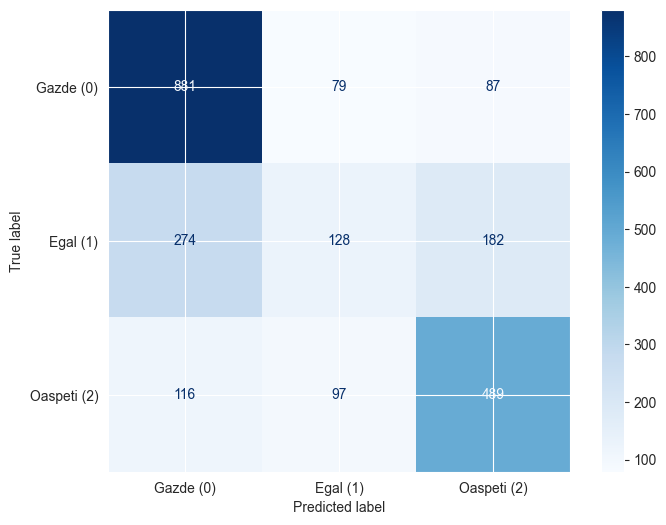

Total Accuracy: 0.64
Total precision : 0.61
Total Recall : 0.64
Total f1-score : 0.61
Total auc_roc : 0.82


In [190]:
from sklearn.linear_model import LogisticRegression
import warnings
from sklearn.exceptions import UndefinedMetricWarning

log_reg_ml = LogisticRegression(random_state=10)
warnings.filterwarnings("ignore", category=UndefinedMetricWarning)
log_reg_ml.fit(X_train_scaled,y_train)
y_pred_logistic = log_reg_ml.predict(X_test_scaled)

print(classification_report(y_true=y_test, y_pred = y_pred_logistic))
acc_logistic = accuracy_score(y_test,y_pred_logistic)
prec_logistic = precision_score(y_test,y_pred_logistic, average='weighted')
f1_logistic = f1_score(y_test,y_pred_logistic, average='weighted')
rec_logistic = recall_score(y_test, y_pred_logistic, average='weighted')
y_probs_logistic = log_reg_ml.predict_proba(X_test_scaled)
auc_roc_logistic = roc_auc_score(y_test,y_probs_logistic, multi_class='ovr', average='weighted')

cm_logistic = confusion_matrix(y_test, y_pred_logistic)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_logistic, display_labels=['Gazde (0)', 'Egal (1)', 'Oaspeti (2)'])
fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(cmap='Blues', ax=ax)
plt.show()

print(f"Total Accuracy: {acc_logistic:.2f}")
print(f"Total precision : {prec_logistic:.2f}")
print(f"Total Recall : {rec_logistic:.2f}")
print(f"Total f1-score : {f1_logistic:.2f}")
print(f"Total auc_roc : {auc_roc_logistic:.2f}")

#### Ce putem observa in datele prezise de Logistic Regression?
- Problema majora a acestui model este faptul ca nu vede asa multe rezultate de egalitate precum modelul anterior.
- Auc_roc ramane asemanator, deci aproximatic la fel separa cazurile pozitive de cele negative.
- O mica imbunatatire apare in clasa gazdelor, unde recall si f1-score cresc putin.

### 3.Decision Tree
Acest model de ML creeaza o forma arborestenta, unde primeste ca input datele noastre, matricea X si in functie de niste conditii, la fiecare nod, merge pe ramura yes sau pe ramura no, pana la frunza.
Ca hiperparametru vom seta noi adancimea maxima.
In plus, modelul urmareste ca deciziile sa fie cat mai semnificative, importante, adica sa clasifice cat mai bine, dar si cat mai repede.

### 3.1 Decision Tree cu parametrii default

              precision    recall  f1-score   support

           0       0.64      0.64      0.64      1047
           1       0.31      0.33      0.32       584
           2       0.57      0.54      0.55       702

    accuracy                           0.53      2333
   macro avg       0.51      0.50      0.50      2333
weighted avg       0.54      0.53      0.53      2333



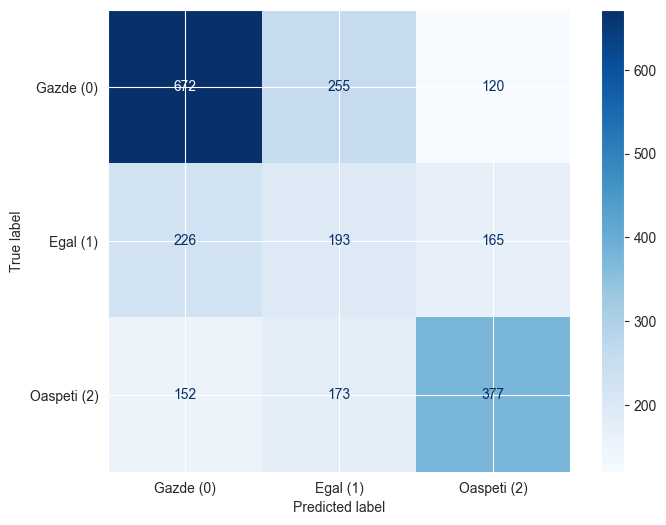

Total Accuracy: 0.53
Total precision : 0.54
Total Recall : 0.53
Total f1-score : 0.53
Total auc_roc : 0.64


In [191]:
from sklearn.tree import DecisionTreeClassifier

dec_tree_ML= DecisionTreeClassifier(random_state=10)

dec_tree_ML.fit(X_train_scaled,y_train)
y_pred_tree = dec_tree_ML.predict(X_test_scaled)
print(classification_report(y_true=y_test, y_pred = y_pred_tree))

acc_tree = accuracy_score(y_test,y_pred_tree)
prec_tree = precision_score(y_test,y_pred_tree, average='weighted')
f1_tree = f1_score(y_test,y_pred_tree, average='weighted')
rec_tree = recall_score(y_test, y_pred_tree, average='weighted')
y_probs_tree = dec_tree_ML.predict_proba(X_test_scaled)
auc_roc_tree = roc_auc_score(y_test,y_probs_tree, multi_class='ovr', average='weighted')

cm_tree = confusion_matrix(y_test, y_pred_tree)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_tree, display_labels=['Gazde (0)', 'Egal (1)', 'Oaspeti (2)'])
fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(cmap='Blues', ax=ax)
plt.show()

print(f"Total Accuracy: {acc_tree:.2f}")
print(f"Total precision : {prec_tree:.2f}")
print(f"Total Recall : {rec_tree:.2f}")
print(f"Total f1-score : {f1_tree:.2f}")
print(f"Total auc_roc : {auc_roc_tree:.2f}")

#### Ce putem observa in datele prezise de Decision Tree?
- metricile sunt putin mai slabe sau egale.
- acum vede si mizeaza pe rezultatele de egal, dar cu costul reducerii celorlalte metrici, inclusiv auc_roc, rezultand faptul ca nu mai difera asa bine intre pozitiv si negativ.


## 4. Random Forest
In acest model de ML, exista mai multi Decision Trees, fiecare are partea sa de date si clasifica in functie de datele pe care le primeste.
Fiecare dintre arbori face o predictie, iar la final toate predictiile se combina si rezulta rezultatul final.
Un punct forte este faptul ca arata ce data din tabel(coloana) are o influenta mare.

### 4.1 Random Forest cu parametrii default

              precision    recall  f1-score   support

           0       0.69      0.82      0.75      1047
           1       0.39      0.25      0.30       584
           2       0.65      0.67      0.66       702

    accuracy                           0.63      2333
   macro avg       0.58      0.58      0.57      2333
weighted avg       0.60      0.63      0.61      2333



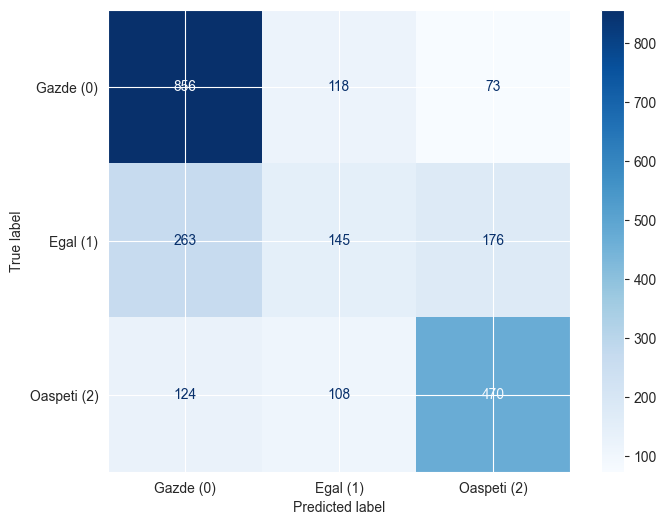

Total Accuracy: 0.63
Total precision : 0.60
Total Recall : 0.63
Total f1-score : 0.61
Total auc_roc : 0.81


In [192]:
from sklearn.ensemble import RandomForestClassifier

rf_Ml =RandomForestClassifier(random_state=10)
rf_Ml.fit(X_train_scaled, y_train)
y_pred_rf =rf_Ml.predict(X_test_scaled)
print(classification_report(y_true=y_test, y_pred = y_pred_rf))

acc_rf = accuracy_score(y_test,y_pred_rf)
prec_rf = precision_score(y_test,y_pred_rf, average='weighted')
f1_rf = f1_score(y_test,y_pred_rf, average='weighted')
rec_rf= recall_score(y_test, y_pred_rf, average='weighted')
y_probs_rf = rf_Ml.predict_proba(X_test_scaled)
auc_roc_rf = roc_auc_score(y_test,y_probs_rf, multi_class='ovr', average='weighted')

cm_rf = confusion_matrix(y_test, y_pred_rf)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=['Gazde (0)', 'Egal (1)', 'Oaspeti (2)'])
fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(cmap='Blues', ax=ax)
plt.show()

print(f"Total Accuracy: {acc_rf:.2f}")
print(f"Total precision : {prec_rf:.2f}")
print(f"Total Recall : {rec_rf:.2f}")
print(f"Total f1-score : {f1_rf:.2f}")
print(f"Total auc_roc : {auc_roc_rf:.2f}")

#### Ce putem observa in datele prezise de Random Forest?
- o imbunatatie per total fata de decision tree, oarecum normala, deoarece sunt mai multi arbori.
- ca performante se apropie de naive bayes si logistic regression, cu mentiunea ca vede egalurile putin mai mult fata de modele mentionate anterior.
- un plus mare fata de logistic regression sunt score-urile de la 'egal'

## 5. Support vector machine
SVM incearca clasificarea prin impartiea spatiului intreg de stari in subspatii, cu ajutorul unor vectori suport.De fapt, se incearca maximizarea marginii, adică a distanței euclidiene dintre hiperplanul de decizie și cele mai apropiate puncte din fiecare clasă, numite vectori suport.
Exista 2 metode pentru clasificare :
- liniara, unde planele sunt impartite cu ajutorul unui vector
- kernel, unde se incearca adaptarea formei geometrice dupa distributia valorilor.


### 5.1 Support Vector Machine cu parametrii default


              precision    recall  f1-score   support

           0       0.68      0.83      0.75      1047
           1       0.41      0.25      0.31       584
           2       0.66      0.65      0.66       702

    accuracy                           0.63      2333
   macro avg       0.59      0.58      0.57      2333
weighted avg       0.61      0.63      0.61      2333



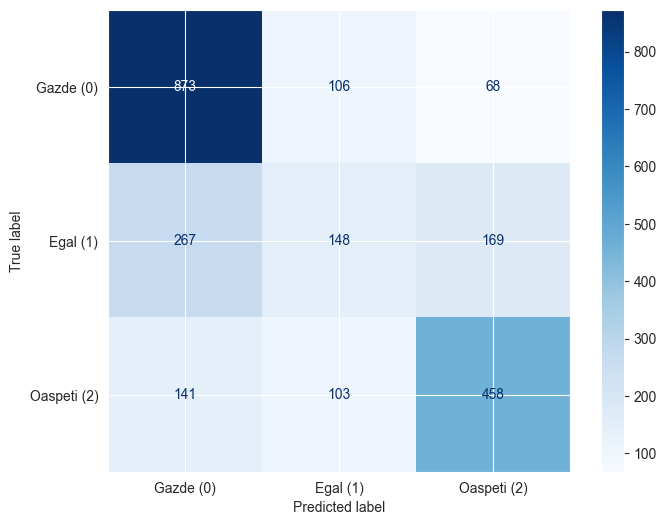

Total Accuracy: 0.63
Total precision : 0.61
Total Recall : 0.63
Total f1-score : 0.61
Total auc_roc : 0.81


In [193]:
from sklearn.svm import SVC

svm_ml = SVC(probability=True, random_state=10)

svm_ml.fit(X_train_scaled, y_train)
y_pred_svm =svm_ml.predict(X_test_scaled)
y_proba_svm = svm_ml.predict_proba(X_test_scaled)

print(classification_report(y_true=y_test, y_pred = y_pred_svm))

acc_svm = accuracy_score(y_test,y_pred_svm)
prec_svm = precision_score(y_test,y_pred_svm, average='weighted')
f1_svm = f1_score(y_test,y_pred_svm, average='weighted')
rec_svm= recall_score(y_test, y_pred_svm, average='weighted')
y_probs_svm = svm_ml.predict_proba(X_test_scaled)
auc_roc_svm = roc_auc_score(y_test,y_probs_svm, multi_class='ovr', average='weighted')

cm_svm = confusion_matrix(y_test, y_pred_svm)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_svm, display_labels=['Gazde (0)', 'Egal (1)', 'Oaspeti (2)'])
fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(cmap='Blues', ax=ax)
plt.show()

print(f"Total Accuracy: {acc_svm:.2f}")
print(f"Total precision : {prec_svm:.2f}")
print(f"Total Recall : {rec_svm:.2f}")
print(f"Total f1-score : {f1_svm:.2f}")
print(f"Total auc_roc : {auc_roc_svm:.2f}")

#### Ce putem observa in datele prezise de Support Vector Machine?
- Se descurca destul de bine pentru rezultatul de victoria gazdelor si pe oaspeti, dar mai putin pentru egalitate.Asta se poate datora si din cauza faptului ca numarul de rezultate de egalitate ca si rezultat final sunt cele mai putine.


## 6. K-Nearest Neighbors
K-Nearest Neighbors este un algoritm de clasificare ML, unde exista mai multe categorii de clase, iar input-ul sau valoarea care trebuie prezisa, ia valoarea clasei ce domina in vecinatatea sa.
Acest model se bazeaza pe urmatorii pasi:
- se calculeaza distanta fata de valoarea pe care dorim sa o clasificam si cele mai apropiate puncte.Distanta poate fi calculata in mai multe moduri, de exemplu: distanta euclidiana, manhattan, minkowski.
- se formeaza un cerc care cuntine *K* vecini (! nu neaparat toate punctele pentru care se calculeaza distanta trebuie sa faca parte din cerc)
- punctul K este clasificat drept clasa dominanta din interiorul cercului.

1. Distanta Euclidiana: $$d(x, y) = \sqrt{\sum_{i=1}^{n} (x_i - y_i)^2}$$
2. Distanta Manhattan: $$d(x, y) = \sum_{i=1}^{n} |x_i - y_i|$$
3. Distanta Minkowski: $$d(x, y) = \left( \sum_{i=1}^{n} |x_i - y_i|^p \right)^{\frac{1}{p}}$$


### 6.1 K-Nearest Neighbors cu parametrii default

              precision    recall  f1-score   support

           0       0.63      0.79      0.70      1047
           1       0.36      0.29      0.32       584
           2       0.66      0.52      0.58       702

    accuracy                           0.58      2333
   macro avg       0.55      0.53      0.54      2333
weighted avg       0.57      0.58      0.57      2333



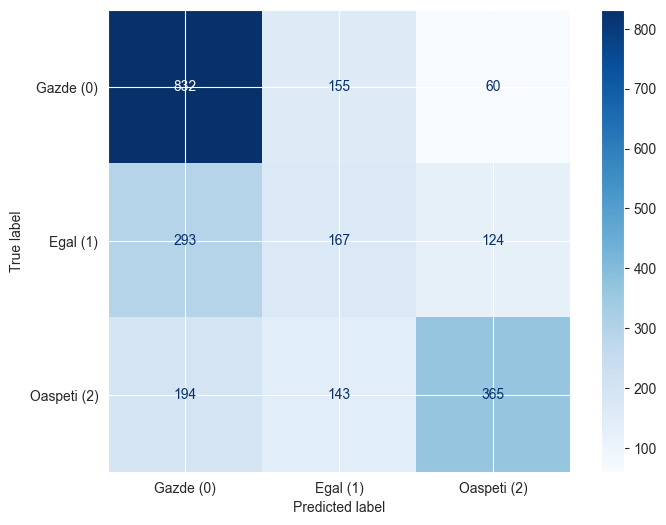

Total Accuracy: 0.58
Total precision : 0.57
Total Recall : 0.58
Total f1-score : 0.57
Total auc_roc : 0.75


In [194]:
from sklearn.neighbors import KNeighborsClassifier

knn_base = KNeighborsClassifier() # nu foloseste random state

knn_base.fit(X_train_scaled, y_train)
y_pred_knn = knn_base.predict(X_test_scaled)
y_proba_knn = knn_base.predict_proba(X_test_scaled)

print(classification_report(y_true=y_test, y_pred = y_pred_knn))

acc_knn = accuracy_score(y_test,y_pred_knn)
prec_knn = precision_score(y_test,y_pred_knn, average='weighted')
f1_knn = f1_score(y_test,y_pred_knn, average='weighted')
rec_knn = recall_score(y_test, y_pred_knn, average='weighted')
y_probs_knn = knn_base.predict_proba(X_test_scaled)
auc_roc_knn = roc_auc_score(y_test,y_probs_knn, multi_class='ovr', average='weighted')

cm_knn = confusion_matrix(y_test, y_pred_knn)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_knn, display_labels=['Gazde (0)', 'Egal (1)', 'Oaspeti (2)'])
fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(cmap='Blues', ax=ax)
plt.show()

print(f"Total Accuracy: {acc_knn:.2f}")
print(f"Total precision : {prec_knn:.2f}")
print(f"Total Recall : {rec_knn:.2f}")
print(f"Total f1-score : {f1_knn:.2f}")
print(f"Total auc_roc : {auc_roc_knn:.2f}")


#### Ce putem observa in datele prezise de K-Nearest Neighbors?
- Rezultate overall sunt putin mai slabe, pierde pe partea de meciuri la oaspeti.
- Modelul vede la fel de bine clasele de clasificare


## 7. Xtreme Gradient Boost
Acest model de Machine Learning are la baza tot modelul _Decision Tree_ , insa complet diferit de _Random Forest_.
Cu ce difera?
- Arborii nu lucreaza paralel, ci concurent.Fiecare arbore se antreneaza pe erorile celui anterior, iar in final se combina predictiile.
- Un avantaj este acela ca previne overfitting.
- Exista si o metoda de regularizare, ce are ca scop penalitatea complexitatii, dupa o formula matematica foarte complexa.

### 7.1 Xtreme Gradient Boost cu parametrii default

              precision    recall  f1-score   support

           0       0.69      0.80      0.74      1047
           1       0.37      0.28      0.32       584
           2       0.65      0.64      0.65       702

    accuracy                           0.62      2333
   macro avg       0.57      0.57      0.57      2333
weighted avg       0.60      0.62      0.61      2333



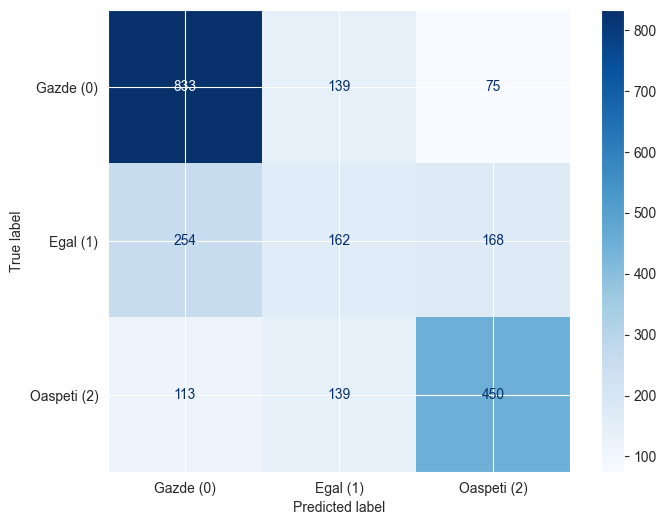

Total Accuracy: 0.62
Total precision : 0.60
Total Recall : 0.62
Total f1-score : 0.61
Total auc_roc : 0.81


In [195]:
from xgboost import XGBClassifier

xgb_base = XGBClassifier(random_state=10)
xgb_base.fit(X_train_scaled, y_train)
y_pred_xgb = xgb_base.predict(X_test_scaled)
y_proba_xgb = xgb_base.predict_proba(X_test_scaled)
print(classification_report(y_true=y_test, y_pred = y_pred_xgb))

acc_xgb = accuracy_score(y_test,y_pred_xgb)
prec_xgb = precision_score(y_test,y_pred_xgb, average='weighted')
f1_xgb = f1_score(y_test,y_pred_xgb, average='weighted')
rec_xgb = recall_score(y_test, y_pred_xgb, average='weighted')
y_probs_xgb = xgb_base.predict_proba(X_test_scaled)
auc_roc_xgb = roc_auc_score(y_test,y_probs_xgb, multi_class='ovr', average='weighted')

cm_xgb = confusion_matrix(y_test, y_pred_xgb)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_xgb, display_labels=['Gazde (0)', 'Egal (1)', 'Oaspeti (2)'])
fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(cmap='Blues', ax=ax)
plt.show()

print(f"Total Accuracy: {acc_xgb:.2f}")
print(f"Total precision : {prec_xgb:.2f}")
print(f"Total Recall : {rec_xgb:.2f}")
print(f"Total f1-score : {f1_xgb:.2f}")
print(f"Total auc_roc : {auc_roc_xgb:.2f}")

#### Ce putem observa in datele prezise de Xtreme Gradient Boost?
- rezultate asemanatoare
- putin mai avansat fata de modelul anterior, cel cu K vecini

## 8. Categorical Boost
Este un model din familia Gradient Boosting, optimizat pentru stabilitate și procesare rapida.
Cu ce se remarca?
- Date categoriale: Gestioneaza automat variabilele de tip text/eticheta, fara a necesita transformari manuale complexe.
- Arbori simetrici: Folosește Oblivious Trees (aceeasi conditie de split pe tot nivelul arborelui), ceea ce previne overfitting-ul.


              precision    recall  f1-score   support

           0       0.69      0.80      0.74      1047
           1       0.38      0.26      0.31       584
           2       0.64      0.65      0.65       702

    accuracy                           0.62      2333
   macro avg       0.57      0.57      0.57      2333
weighted avg       0.60      0.62      0.61      2333



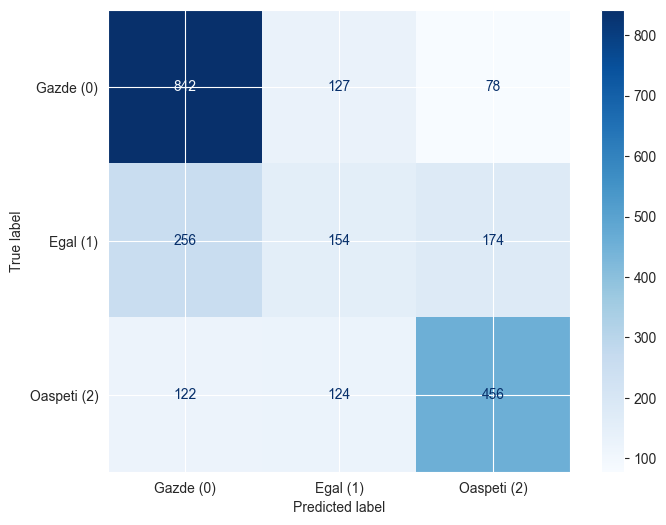

Total Accuracy: 0.62
Total precision : 0.60
Total Recall : 0.62
Total f1-score : 0.61
Total auc_roc : 0.81


In [196]:
from catboost import CatBoostClassifier

cat_base = CatBoostClassifier(verbose=0,random_state=10)
cat_base.fit(X_train_scaled, y_train)
y_pred_cat = cat_base.predict(X_test_scaled)
y_proba_cat = cat_base.predict_proba(X_test_scaled)
print(classification_report(y_true=y_test, y_pred = y_pred_cat))

acc_cat = accuracy_score(y_test,y_pred_cat)
prec_cat = precision_score(y_test,y_pred_cat, average='weighted')
f1_cat = f1_score(y_test,y_pred_cat, average='weighted')
rec_cat = recall_score(y_test, y_pred_cat, average='weighted')
y_probs_cat = cat_base.predict_proba(X_test_scaled)
auc_roc_cat = roc_auc_score(y_test,y_probs_cat, multi_class='ovr', average='weighted')

cm_cat = confusion_matrix(y_test, y_pred_cat)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_cat, display_labels=['Gazde (0)', 'Egal (1)', 'Oaspeti (2)'])
fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(cmap='Blues', ax=ax)
plt.show()

print(f"Total Accuracy: {acc_cat:.2f}")
print(f"Total precision : {prec_cat:.2f}")
print(f"Total Recall : {rec_cat:.2f}")
print(f"Total f1-score : {f1_cat:.2f}")
print(f"Total auc_roc : {auc_roc_cat:.2f}")


#### Ce putem observa in datele prezise de Categorical Boost?
- printre cele mai echilibrate modele de Machine Learning
- problema comuna ar fi la egalitate


## 9. Explainable Boosting Machine
- Analizeaza fiecare trasatura separat: Modelul invata o funcție pentru fiecare coloana
- Rezultatul final este suma acestor analize.
- Exista si perechi de variabile care interactioneaza.

              precision    recall  f1-score   support

           0       0.70      0.82      0.76      1047
           1       0.42      0.29      0.34       584
           2       0.66      0.66      0.66       702

    accuracy                           0.64      2333
   macro avg       0.59      0.59      0.59      2333
weighted avg       0.62      0.64      0.63      2333



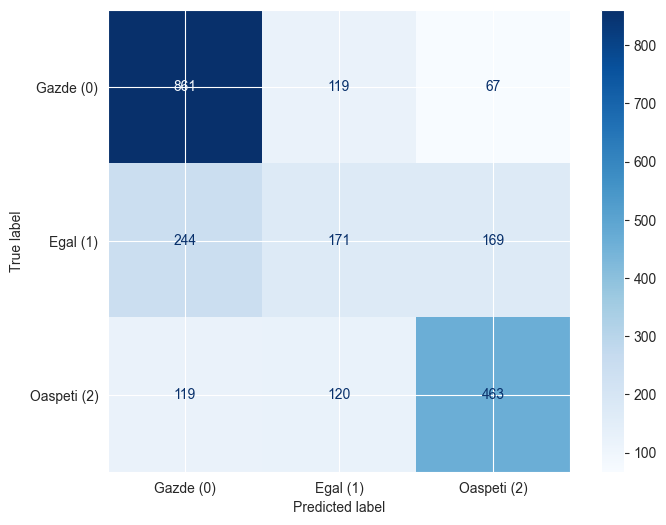

Total Accuracy: 0.64
Total precision : 0.62
Total Recall : 0.64
Total f1-score : 0.63
Total auc_roc : 0.83


In [197]:
from interpret.glassbox import ExplainableBoostingClassifier

warnings.filterwarnings("ignore", category=UserWarning)
ebm_ml = ExplainableBoostingClassifier(random_state=10)
ebm_ml.fit(X_train_scaled, y_train)
y_pred_ebm = ebm_ml.predict(X_test_scaled)
y_proba_ebm = ebm_ml.predict_proba(X_test_scaled)
print(classification_report(y_true=y_test, y_pred = y_pred_ebm))

acc_ebm = accuracy_score(y_test,y_pred_ebm)
prec_ebm = precision_score(y_test,y_pred_ebm, average='weighted')
f1_ebm = f1_score(y_test,y_pred_ebm, average='weighted')
rec_ebm = recall_score(y_test, y_pred_ebm, average='weighted')
y_probs_ebm = ebm_ml.predict_proba(X_test_scaled)
auc_roc_ebm = roc_auc_score(y_test,y_probs_ebm, multi_class='ovr', average='weighted')

cm_ebm = confusion_matrix(y_test, y_pred_ebm)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_ebm, display_labels=['Gazde (0)', 'Egal (1)', 'Oaspeti (2)'])
fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(cmap='Blues', ax=ax)
plt.show()

print(f"Total Accuracy: {acc_ebm:.2f}")
print(f"Total precision : {prec_ebm:.2f}")
print(f"Total Recall : {rec_ebm:.2f}")
print(f"Total f1-score : {f1_ebm:.2f}")
print(f"Total auc_roc : {auc_roc_ebm:.2f}")


#### Ce putem observa in datele prezise de Explainable Boosting Machine?
- rezultate asemanatoare, pare ca limitarea este in vecinatatea procentului de 60%.


### Cateva concluzii dupa modelele ML cu parametrii de baza:
- Cea mai buna acuratete din aceste modele de baza este de aproximativ 60%. As tinde sa spun in mod obiectiv faptul ca, in acest context, de a prezice echipa castigatoare dintr-un meci de fotbal in Anglia este acceptabil, deoarece fara acest ajutor, probabilitatea ar fi de 33% pentru a 'nimeri'.
- O problema de la dataset ar fi ca sunt prea putine egaluri si poate din acest motiv nu sunt vazute asa bine.In plus, am incercat sa pun feature relevante, care influenteaza(poate cu adevarat) rezultatul, despre forma echipei.In ciuda faptului ca nu detin alte informatii relevante care au si influenta mai mare asupra rezultatului(daca e meci important, jucatori accidentati, etc), am incercat sa prelucrez datele detinute.

# Analiza comparativa

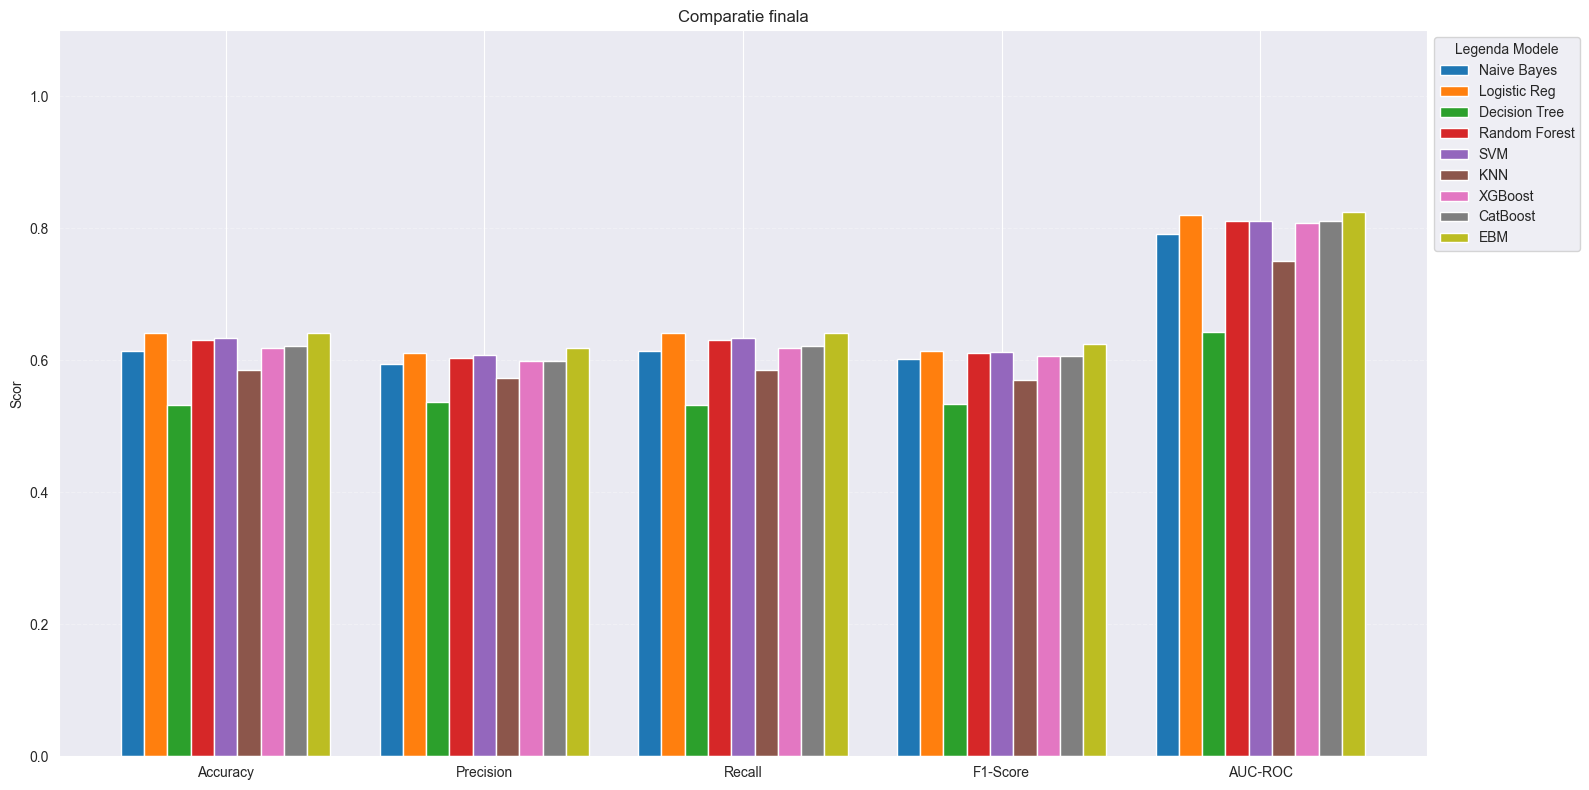

In [198]:
models_data = {
    'Naive Bayes':   [acc_bayes, prec_bayes, rec_bayes, f1_bayes, roc_auc_bayes],
    'Logistic Reg':  [acc_logistic, prec_logistic, rec_logistic, f1_logistic, auc_roc_logistic],
    'Decision Tree': [acc_tree, prec_tree, rec_tree, f1_tree, auc_roc_tree],
    'Random Forest': [acc_rf, prec_rf, rec_rf, f1_rf, auc_roc_rf],
    'SVM':           [acc_svm, prec_svm, rec_svm, f1_svm, auc_roc_svm],
    'KNN':           [acc_knn, prec_knn, rec_knn, f1_knn, auc_roc_knn],
    'XGBoost':       [acc_xgb, prec_xgb, rec_xgb, f1_xgb, auc_roc_xgb],
    'CatBoost':      [acc_cat, prec_cat, rec_cat, f1_cat, auc_roc_cat],
    'EBM':           [acc_ebm, prec_ebm, rec_ebm, f1_ebm, auc_roc_ebm]
}

metric_names = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC-ROC']
x = np.arange(len(metric_names))
total_models = len(models_data)
width = 0.09

fig, ax = plt.subplots(figsize=(16, 8))
for i, (model_name, scores) in enumerate(models_data.items()):
    offset = (i - total_models/2) * width + width/2
    ax.bar(x + offset, scores, width, label=model_name)

ax.set_ylabel('Scor')
ax.set_title('Comparatie finala')
ax.set_xticks(x)
ax.set_xticklabels(metric_names)
ax.legend(loc='upper left', bbox_to_anchor=(1, 1), title="Legenda Modele")
ax.set_ylim(0, 1.1)
ax.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

#### Mai sus se poate observa grafic cu toate modelele comparate in functie de score-uri.
Ideea pentru a creea un top: Vom face o medie ponderata a score-urilor, fiecare avand o pondere care reprezinta importanta.Toate sunt importante, insa depinde de context importanta metricilor.(de ex auc_roc sa fie 0.1, dintr-un total de 1.0).
Recall si precision vor avea aceeasi pondere, deoarece si false positive si false negative sunt la fel de 'dureroase'/importante in acest context.

In [199]:
weights = {
    'Accuracy': 0.20,
    'Precision': 0.15,
    'Recall': 0.15,
    'F1-Score': 0.40,
    'AUC-ROC': 0.10
}

df_results = pd.DataFrame.from_dict(models_data, orient='index', columns=metric_names)
df_results['Weighted_Score'] = (
    df_results['Accuracy'] * weights['Accuracy'] +
    df_results['Precision'] * weights['Precision'] +
    df_results['Recall'] * weights['Recall'] +
    df_results['F1-Score'] * weights['F1-Score'] +
    df_results['AUC-ROC'] * weights['AUC-ROC']
)
top_5_final = df_results.sort_values(by='Weighted_Score', ascending=False).head(5)

print("Top 5 :")
display(top_5_final[['Weighted_Score', 'F1-Score', 'Accuracy', 'AUC-ROC','Recall','Precision']])

Top 5 :


,Weighted_Score,F1-Score,Accuracy,AUC-ROC,Recall,Precision
EBM,0.649832,0.625298,0.640806,0.825212,0.640806,0.619396
Logistic Reg,0.644351,0.614860,0.642092,0.820863,0.642092,0.610588
SVM,0.639195,0.612622,0.633948,0.810786,0.633948,0.607908
Random Forest,0.636639,0.610567,0.630519,0.811934,0.630519,0.603583
CatBoost,0.631169,0.605948,0.622375,0.811514,0.622375,0.598715


In [200]:
top_5_final.to_csv("../Datasets/Scores_clasificare.csv")

# Ajustarea hiperparametrilor si curbele de invatare a top 5 modele:
Pentru hiperparametrii voi folosi clasa GridSearchCV. O atentie sporita trebuie avuta la cazurile de overfitting si underfitting.
1. Underfitting = atunci cand un model este prea slab si nu acopera toate cazurile reale posibile
2. Overfitting = atunci cand un model este prea bun si invata inclusiv cazurile speciale, care sunt foarte greu de prezis.

__Curba de invatare__
- Vor exista 2 curbe, una de validare, alta antrenare.
- Cand cele 2 se aproprie foarte mult si foarte repede rezulta underfitting, iar cand este un spatiu prea mare rezulta overfitting.

Link-uri utile pentru hiperparametrii :
- https://interpret.ml/docs/hyperparameters.html
- https://scikit-learn.org/stable/modules/svm.html

Un parametru util la un ML ar fi **class_weight='balanced**, pentru ca modelul sa fie penalizat mai mult atunci cand greseste la o clasa care are un numar mai mic.

In plus, dorim sa gasim cel mai bun model in functie de *f1_weighted*, deoarece ignorarea rezultatului de egalitate trebuie sa fie penalizata. Totodata, am vazut ca precizia poate fi mare sau acuratetea, deoarece e ridicata de celelalte 2 clase.
In concluzie, consider ca f1 este cel mai bun scor de masurat, in plus, calculam f1 ponderat.


## 1. Explainable Boosting Machine

In [201]:
ebm_grid = {
    'smoothing_rounds': [65, 70, 75],
    'learning_rate': [0.005, 0.01, 0.02],
    'interactions': [5,10],
    'outer_bags': [8, 12],
    'min_samples_leaf': [2, 5],
    'max_bins': [256],
    'early_stopping_rounds': [50]
}

ebm_base = ExplainableBoostingClassifier(
    random_state=10,
    n_jobs=-1,
)

grid_search_ebm = GridSearchCV(
    estimator=ebm_base,
    param_grid=ebm_grid,
    scoring='f1_weighted',
    cv=5,
    n_jobs=-1,
    verbose=1
)

grid_search_ebm.fit(X_train_scaled, y_train)
best_ebm = grid_search_ebm.best_estimator_
y_pred_ebm_opt = best_ebm.predict(X_test_scaled)
y_probs_ebm_opt = best_ebm.predict_proba(X_test_scaled)
acc_ebm_opt = accuracy_score(y_test, y_pred_ebm_opt)
prec_ebm_opt = precision_score(y_test, y_pred_ebm_opt, average='weighted')
rec_ebm_opt = recall_score(y_test, y_pred_ebm_opt, average='weighted')
f1_ebm_opt = f1_score(y_test, y_pred_ebm_opt, average='weighted')
auc_roc_ebm_opt = roc_auc_score(y_test, y_probs_ebm_opt, multi_class='ovr', average='weighted')

print(classification_report(y_test, y_pred_ebm_opt, target_names=['Gazde (0)', 'Egal (1)', 'Oaspeti (2)']))
cm_ebm_opt = confusion_matrix(y_test, y_pred_ebm_opt)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_ebm_opt, display_labels=['Gazde (0)', 'Egal (1)', 'Oaspeti (2)'])
fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(cmap='Blues', ax=ax)
ax.set_title("Matricea de Confuzie: EBM Optimizat")
plt.show()

print(f"Total Accuracy: {acc_ebm_opt:.2f}")
print(f"Total precision : {prec_ebm_opt:.2f}")
print(f"Total Recall : {rec_ebm_opt:.2f}")
print(f"Total f1-score : {f1_ebm_opt:.2f}")
print(f"Total auc_roc : {auc_roc_ebm_opt:.2f}")

Fitting 5 folds for each of 72 candidates, totalling 360 fits



KeyboardInterrupt



#### Modelul hiperparametrizat este la fel ca cel default.
*Curba de invatare:*

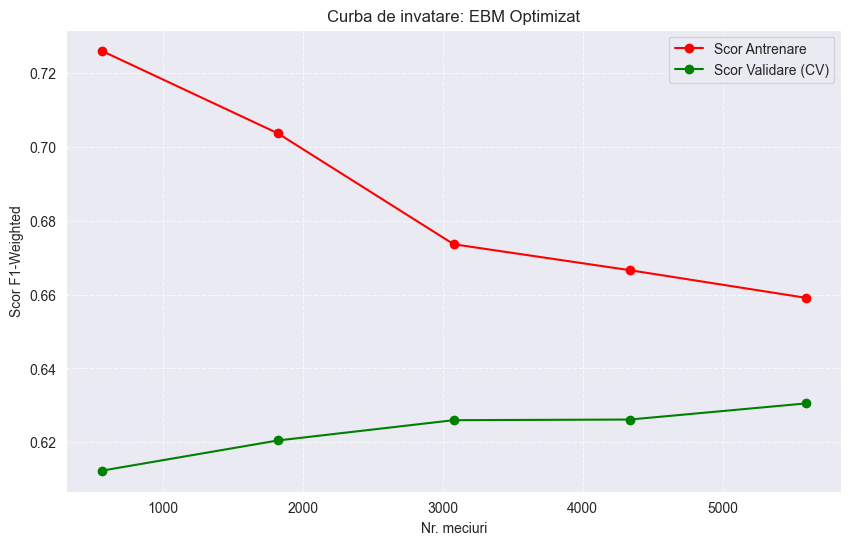

In [102]:
from Classes.Utils import plot_learning_curve

plot_learning_curve(best_ebm, X_train_scaled, y_train, "Curba de invatare: EBM Optimizat")

Curba de invatare de mai sus nu prezinta niciun fenomen extrem, de underfitting sau overfitting. Cea de antrenare creste usor, iar cea de antrenare scade usor. Gap-ul dintre ele probabil se stabilizeaza undeva pe la 0.03, arantand faptul ca modelului ii foloseste ceea ce invata.

## 2. Support Vector Machine

Fitting 5 folds for each of 18 candidates, totalling 90 fits
              precision    recall  f1-score   support

   Gazde (0)       0.79      0.67      0.72      1047
    Egal (1)       0.37      0.51      0.43       584
 Oaspeti (2)       0.68      0.63      0.65       702

    accuracy                           0.62      2333
   macro avg       0.61      0.60      0.60      2333
weighted avg       0.65      0.62      0.63      2333



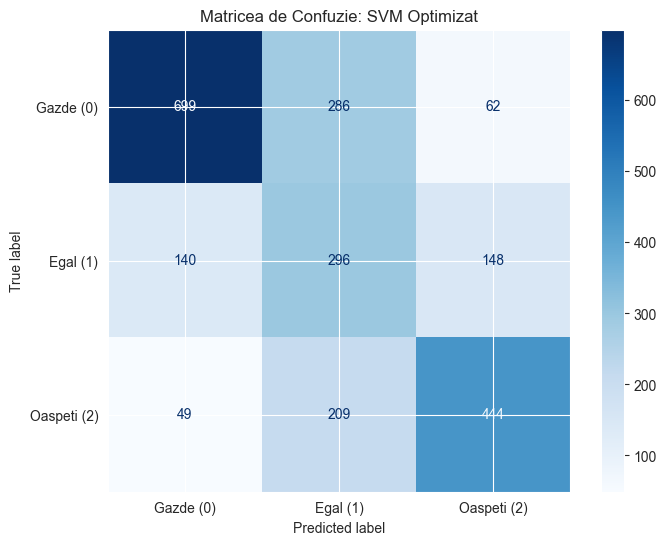

Total Accuracy: 0.62
Total precision : 0.65
Total Recall : 0.62
Total f1-score : 0.63
Total auc_roc : 0.82


In [103]:

svm_grid = {
    "C": [0.1, 1, 10],
    "kernel": ["linear", "rbf"],
    "gamma": ["scale", 0.01, 0.1],
    'class_weight': ['balanced'],
    "decision_function_shape": ['ovr']
}

svm_base = SVC(
    random_state=10,
    probability=True,
)

grid_search_svm = GridSearchCV(
    estimator=svm_base,
    param_grid=svm_grid,
    n_jobs=-1,
    cv=5,
    scoring='f1_weighted',
    verbose=1
)

grid_search_svm.fit(X_train_scaled, y_train)
best_svm = grid_search_svm.best_estimator_
y_pred_svm_opt = best_svm.predict(X_test_scaled)
y_probs_svm_opt = best_svm.predict_proba(X_test_scaled)
acc_svm_opt = accuracy_score(y_test, y_pred_svm_opt)
prec_svm_opt = precision_score(y_test, y_pred_svm_opt, average='weighted')
rec_svm_opt = recall_score(y_test, y_pred_svm_opt, average='weighted')
f1_svm_opt = f1_score(y_test, y_pred_svm_opt, average='weighted')
auc_roc_svm_opt = roc_auc_score(y_test, y_probs_svm_opt, multi_class='ovr', average='weighted')

print(classification_report(y_test, y_pred_svm_opt, target_names=['Gazde (0)', 'Egal (1)', 'Oaspeti (2)']))
cm_svm_opt = confusion_matrix(y_test, y_pred_svm_opt)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_svm_opt, display_labels=['Gazde (0)', 'Egal (1)', 'Oaspeti (2)'])
fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(cmap='Blues', ax=ax)
ax.set_title("Matricea de Confuzie: SVM Optimizat")
plt.show()

print(f"Total Accuracy: {acc_svm_opt:.2f}")
print(f"Total precision : {prec_svm_opt:.2f}")
print(f"Total Recall : {rec_svm_opt:.2f}")
print(f"Total f1-score : {f1_svm_opt:.2f}")
print(f"Total auc_roc : {auc_roc_svm_opt:.2f}")


Aceasta varianta de Support vector machine,optimizata, are la prima vede rezultate asemanatoare.
Optimizarea majora este pe partea rezultatului de egalitate si ofera niste estimari mult mai realiste.

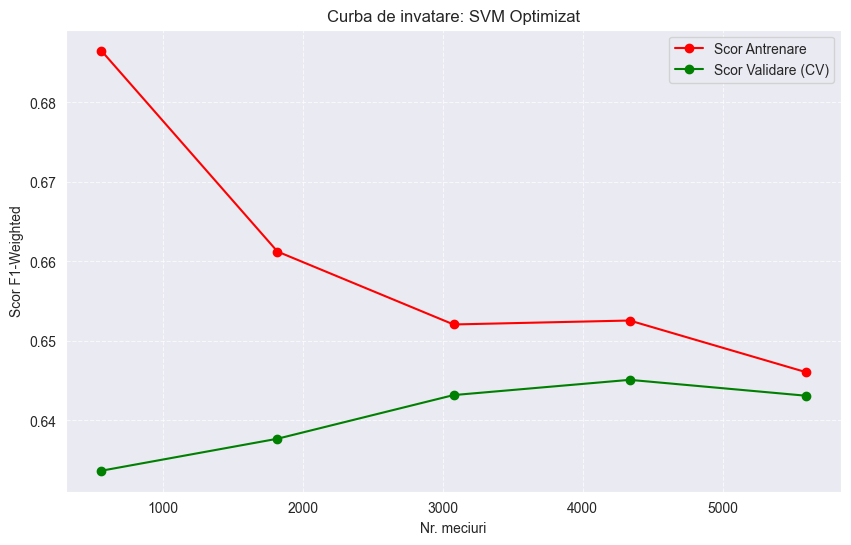

In [104]:
from Classes.Utils import plot_learning_curve

plot_learning_curve(best_svm, X_train_scaled, y_train, "Curba de invatare: SVM Optimizat")


In curba de mai sus nu este prezent fenomenul de overfitting, nici de underfitting, cu mentiunea ca cele 2 curbe sa nu se devina una si aceeasi de la un punct. Odata ce creste numarul de meciuri, asta implica si rezultate sau situatii noi, precizia/ acuratetea scade.

## 3. Logistic Regression

Fitting 5 folds for each of 10 candidates, totalling 50 fits
              precision    recall  f1-score   support

   Gazde (0)       0.79      0.70      0.75      1047
    Egal (1)       0.38      0.47      0.42       584
 Oaspeti (2)       0.67      0.65      0.66       702

    accuracy                           0.63      2333
   macro avg       0.62      0.61      0.61      2333
weighted avg       0.65      0.63      0.64      2333



C:\Facultate\An_3\Semestrul_2\SI\Lab\proiect-ml-RazvanBarna\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


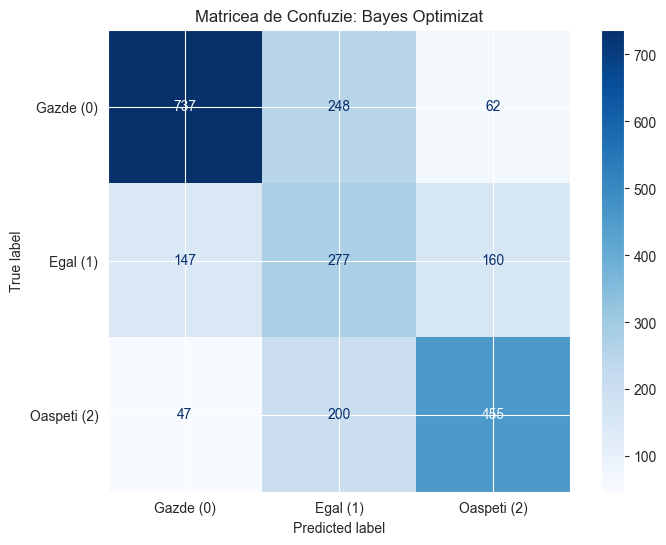

Total Accuracy: 0.63
Total precision : 0.65
Total Recall : 0.63
Total f1-score : 0.64
Total auc_roc : 0.82


In [105]:
log_grid = {
    'C': [0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2'],
    'solver': ['saga'],
    'class_weight': ['balanced'],
    'max_iter': [2000]
}
log_base = LogisticRegression(random_state=10)
grid_search_log = GridSearchCV(
    estimator=log_base,
    param_grid=log_grid,
    cv=5,
    scoring='f1_weighted',
    verbose=1,
    n_jobs=-1
)

grid_search_log.fit(X_train_scaled, y_train)
best_log = grid_search_log.best_estimator_
y_pred_log_opt = best_log.predict(X_test_scaled)
y_probs_log_opt = best_log.predict_proba(X_test_scaled)
acc_log_opt = accuracy_score(y_test, y_pred_log_opt)
prec_log_opt = precision_score(y_test, y_pred_log_opt, average='weighted')
rec_log_opt = recall_score(y_test, y_pred_log_opt, average='weighted')
f1_log_opt = f1_score(y_test, y_pred_log_opt, average='weighted')
auc_roc_log_opt = roc_auc_score(y_test, y_probs_log_opt, multi_class='ovr', average='weighted')

print(classification_report(y_test, y_pred_log_opt, target_names=['Gazde (0)', 'Egal (1)', 'Oaspeti (2)']))
cm_log_opt = confusion_matrix(y_test, y_pred_log_opt)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_log_opt, display_labels=['Gazde (0)', 'Egal (1)', 'Oaspeti (2)'])
fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(cmap='Blues', ax=ax)
ax.set_title("Matricea de Confuzie: Bayes Optimizat")
plt.show()

print(f"Total Accuracy: {acc_log_opt:.2f}")
print(f"Total precision : {prec_log_opt:.2f}")
print(f"Total Recall : {rec_log_opt:.2f}")
print(f"Total f1-score : {f1_log_opt:.2f}")
print(f"Total auc_roc : {auc_roc_log_opt:.2f}")

Rezultatele sunt asemanatoare cu modelul default.

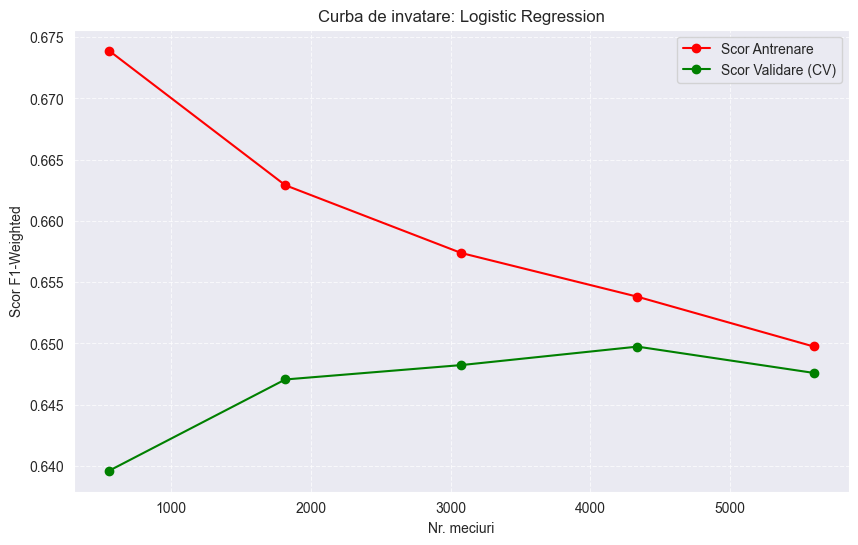

In [106]:
plot_learning_curve(best_log, X_train_scaled, y_train, "Curba de invatare: Logistic Regression")


- Din graficul de mai sus rezulta o diferenta sutimi intre scorul de antrenare si validare, ceea ce inseamna, din pacate underfitting. Acest lucru se cauzeaza datorita faptului ca modelul Logistic Regression este unul simplu, mult prea simplu pentru o clasificare complexa pe care o incerc.
- Spre deosebire de EBM și SVM, aici curbele coboara foarte repede si ajung una langa alta, la o diferenta de sutimi.

## 4. Categorical Boost

Fitting 5 folds for each of 8 candidates, totalling 40 fits
0:	learn: 1.0792711	total: 1.84ms	remaining: 1.84s
1:	learn: 1.0611187	total: 3.42ms	remaining: 1.7s
2:	learn: 1.0442322	total: 4.95ms	remaining: 1.65s
3:	learn: 1.0269168	total: 6.47ms	remaining: 1.61s
4:	learn: 1.0128269	total: 8.06ms	remaining: 1.6s
5:	learn: 0.9982609	total: 9.63ms	remaining: 1.6s
6:	learn: 0.9854557	total: 11.3ms	remaining: 1.61s
7:	learn: 0.9735515	total: 12.9ms	remaining: 1.6s
8:	learn: 0.9637147	total: 14.4ms	remaining: 1.59s
9:	learn: 0.9560187	total: 16.2ms	remaining: 1.61s
10:	learn: 0.9473876	total: 18.1ms	remaining: 1.63s
11:	learn: 0.9381346	total: 19.7ms	remaining: 1.62s
12:	learn: 0.9312906	total: 21.2ms	remaining: 1.61s
13:	learn: 0.9258229	total: 22.7ms	remaining: 1.6s
14:	learn: 0.9203130	total: 24.3ms	remaining: 1.59s
15:	learn: 0.9154346	total: 26.1ms	remaining: 1.6s
16:	learn: 0.9100948	total: 27.7ms	remaining: 1.6s
17:	learn: 0.9054389	total: 29.3ms	remaining: 1.6s
18:	learn: 0.9007874	t

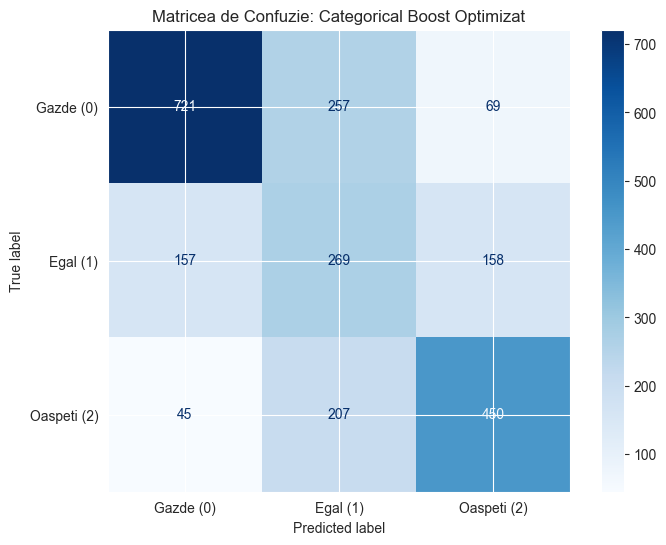

Total Accuracy: 0.62
Total precision : 0.64
Total Recall : 0.62
Total f1-score : 0.63
Total auc_roc : 0.82


In [107]:
cb_grid = {
    'iterations': [1000],
    'depth': [4, 6],
    'learning_rate': [0.01, 0.05],
    'l2_leaf_reg': [5, 7],
    'border_count': [254],
}

cb_base = CatBoostClassifier(
    loss_function='MultiClass',
    auto_class_weights='Balanced',
    random_state=10,
)

grid_search_catB = GridSearchCV(
    estimator=cb_base,
    param_grid= cb_grid,
    n_jobs=-1,
    cv=5,
    verbose=1,
)

grid_search_catB.fit(X_train_scaled, y_train)
best_catB = grid_search_catB.best_estimator_
y_pred_catB_opt = best_catB.predict(X_test_scaled)
y_probs_catB_opt = best_catB.predict_proba(X_test_scaled)
acc_catB_opt = accuracy_score(y_test, y_pred_catB_opt)
prec_catB_opt = precision_score(y_test, y_pred_catB_opt, average='weighted')
rec_catB_opt = recall_score(y_test, y_pred_catB_opt, average='weighted')
f1_catB_opt = f1_score(y_test, y_pred_catB_opt, average='weighted')
auc_roc_catB_opt = roc_auc_score(y_test, y_probs_catB_opt, multi_class='ovr', average='weighted')

print(classification_report(y_test, y_pred_catB_opt, target_names=['Gazde (0)', 'Egal (1)', 'Oaspeti (2)']))
cm_catB_opt = confusion_matrix(y_test, y_pred_catB_opt)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_catB_opt, display_labels=['Gazde (0)', 'Egal (1)', 'Oaspeti (2)'])
fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(cmap='Blues', ax=ax)
ax.set_title("Matricea de Confuzie: Categorical Boost Optimizat")
plt.show()

print(f"Total Accuracy: {acc_catB_opt:.2f}")
print(f"Total precision : {prec_catB_opt:.2f}")
print(f"Total Recall : {rec_catB_opt:.2f}")
print(f"Total f1-score : {f1_catB_opt:.2f}")
print(f"Total auc_roc : {auc_roc_catB_opt:.2f}")



Categorical Boost Optimizat are rezultate asemanatoare cu restul.

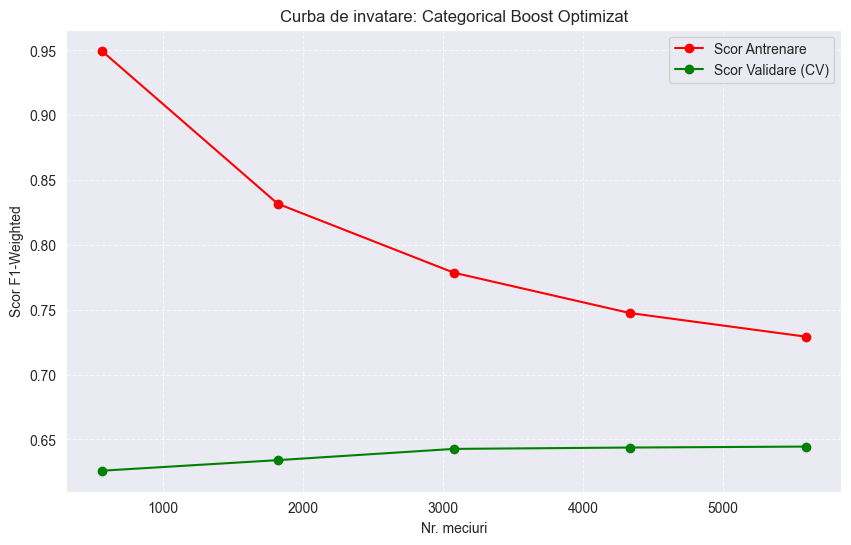

In [108]:
from Classes.Utils import plot_learning_curve

plot_learning_curve(best_catB, X_train_scaled, y_train, "Curba de invatare: Categorical Boost Optimizat")


In curba de invatare de mai sus, putem observa o diferenta mare intre cele 2 score-uri, rezultand overfitting.
Din nou, datele nu sunt suficiente in cazul egalului, modelul nu stie exact.

## 5. Random Forest

Fitting 5 folds for each of 96 candidates, totalling 480 fits
              precision    recall  f1-score   support

   Gazde (0)       0.69      0.83      0.76      1047
    Egal (1)       0.42      0.23      0.29       584
 Oaspeti (2)       0.64      0.69      0.66       702

    accuracy                           0.64      2333
   macro avg       0.58      0.58      0.57      2333
weighted avg       0.61      0.64      0.61      2333



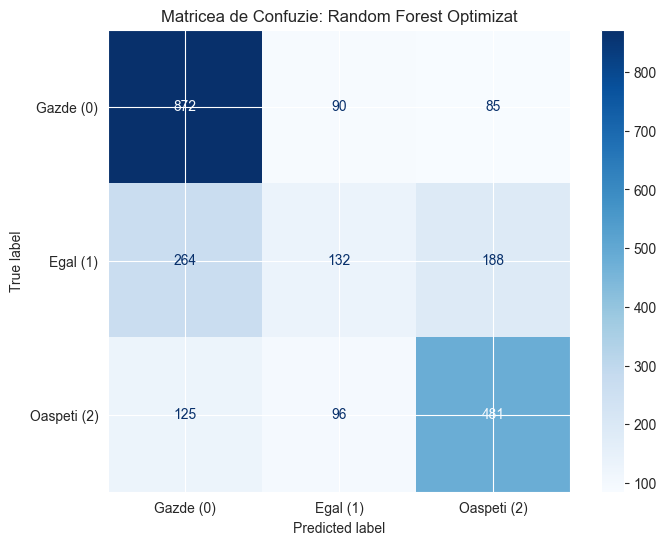

Total Accuracy: 0.64
Total Precision: 0.61
Total Recall: 0.64
Total F1-score: 0.61
Total AUC-ROC: 0.82


In [109]:
rf_grid = {
    'n_estimators': [200, 300],
    'max_depth': [5, 8, 10,15],
    'min_samples_split': [20,50],
    'min_samples_leaf': [5, 10, 20],
    'max_features': ['sqrt'],
    'max_samples': [0.6, 0.8]
}

rf_base = RandomForestClassifier(
    random_state=10,
    n_jobs=-1,
)

grid_search_rf = GridSearchCV(
    estimator=rf_base,
    param_grid=rf_grid,
    cv=5,
    scoring="f1_weighted",
    verbose=1,
    n_jobs=-1,
)

grid_search_rf.fit(X_train_scaled, y_train)
best_rf = grid_search_rf.best_estimator_
y_pred_rf_opt = best_rf.predict(X_test_scaled)
y_probs_rf_opt = best_rf.predict_proba(X_test_scaled)

acc_rf_opt = accuracy_score(y_test, y_pred_rf_opt)
prec_rf_opt = precision_score(y_test, y_pred_rf_opt, average='weighted')
rec_rf_opt = recall_score(y_test, y_pred_rf_opt, average='weighted')
f1_rf_opt = f1_score(y_test, y_pred_rf_opt, average='weighted')
auc_roc_rf_opt = roc_auc_score(y_test, y_probs_rf_opt, multi_class='ovr', average='weighted')

print(classification_report(y_test, y_pred_rf_opt, target_names=['Gazde (0)', 'Egal (1)', 'Oaspeti (2)']))

cm_rf_opt = confusion_matrix(y_test, y_pred_rf_opt)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_rf_opt, display_labels=['Gazde (0)', 'Egal (1)', 'Oaspeti (2)'])
fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(cmap='Blues', ax=ax)
ax.set_title("Matricea de Confuzie: Random Forest Optimizat")
plt.show()

print(f"Total Accuracy: {acc_rf_opt:.2f}")
print(f"Total Precision: {prec_rf_opt:.2f}")
print(f"Total Recall: {rec_rf_opt:.2f}")
print(f"Total F1-score: {f1_rf_opt:.2f}")
print(f"Total AUC-ROC: {auc_roc_rf_opt:.2f}")

Acuratetea, recall-ul si f1-score fata de celelalte modele, deoarece proportia pe egaluri este mai mica.

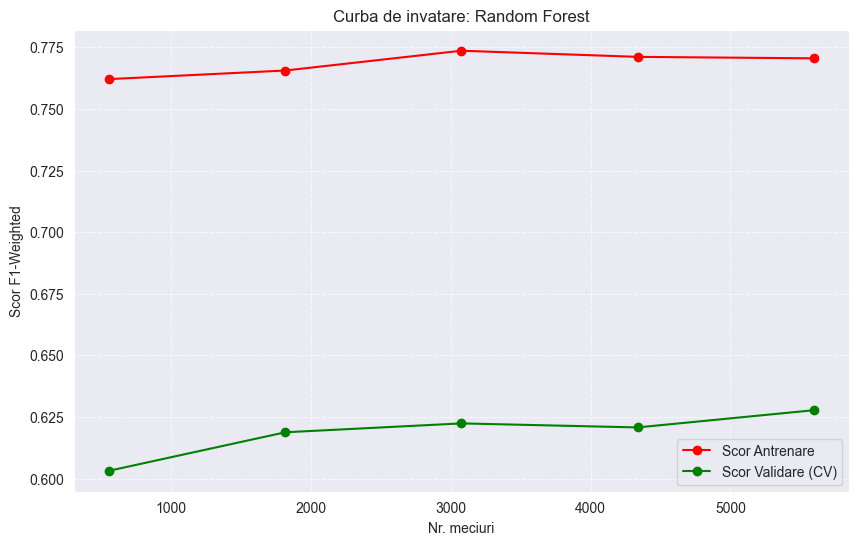

In [110]:
plot_learning_curve(best_rf, X_train_scaled, y_train, "Curba de invatare: Random Forest")


Curba de invatare de mai sus poate prezinta un usor overfitting. Initial, acesta a fost mult mai mare, dublu, dar prin ajustarea parametrilor am reusit sa ajustez aceasta eroare si sa o fac minima.

### Analiza comparativa intre modelele optimizate

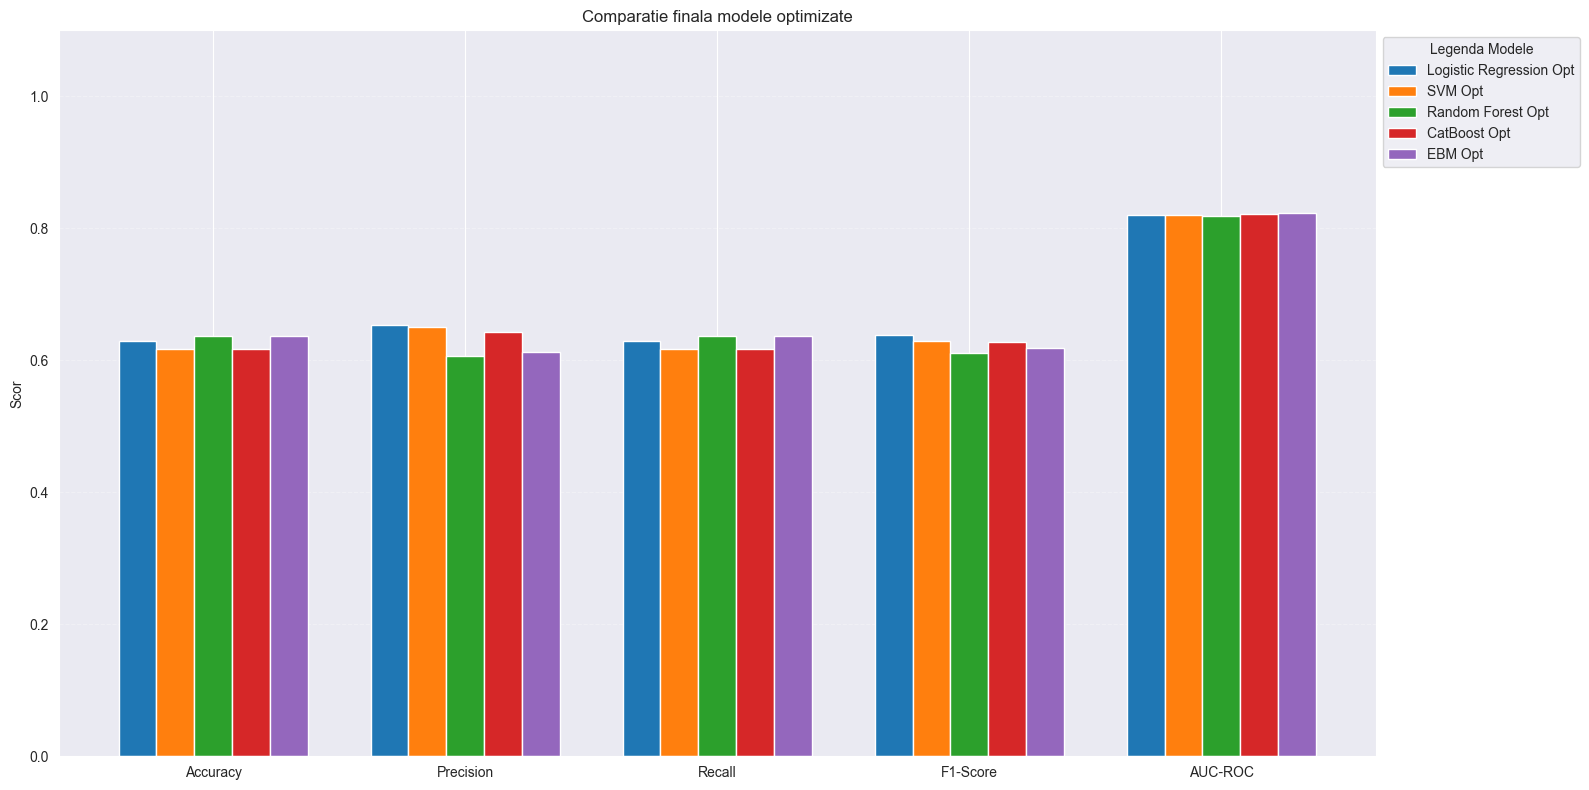

In [111]:
models_data_opt = {
    'Logistic Regression Opt':   [acc_log_opt, prec_log_opt, rec_log_opt, f1_log_opt, auc_roc_log_opt],
    'SVM Opt':           [acc_svm_opt, prec_svm_opt, rec_svm_opt, f1_svm_opt, auc_roc_svm_opt],
    'Random Forest Opt':       [acc_rf_opt, prec_rf_opt, rec_rf_opt, f1_rf_opt, auc_roc_rf_opt],
    'CatBoost Opt':      [acc_catB_opt, prec_catB_opt, rec_catB_opt, f1_catB_opt, auc_roc_catB_opt],
    'EBM Opt':           [acc_ebm_opt, prec_ebm_opt, rec_ebm_opt, f1_ebm_opt, auc_roc_ebm_opt],
}

metric_names = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC-ROC']
x = np.arange(len(metric_names))
total_models_opt = len(models_data_opt)
width = 0.15

fig, ax = plt.subplots(figsize=(16, 8))
for i, (model_name, scores) in enumerate(models_data_opt.items()):
    offset = (i - total_models_opt/2) * width + width/2
    ax.bar(x + offset, scores, width, label=model_name)

ax.set_ylabel('Scor')
ax.set_title('Comparatie finala modele optimizate')
ax.set_xticks(x)
ax.set_xticklabels(metric_names)
ax.legend(loc='upper left', bbox_to_anchor=(1, 1), title="Legenda Modele")
ax.set_ylim(0, 1.1)
ax.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

### Cele mai bune top 3 modele optimizate

In [112]:
df_results_opt = pd.DataFrame.from_dict(models_data_opt, orient='index', columns=metric_names)
df_results_opt['Weighted_Score'] = (
    df_results_opt['Accuracy'] * weights['Accuracy'] +
    df_results_opt['Precision'] * weights['Precision'] +
    df_results_opt['Recall'] * weights['Recall'] +
    df_results_opt['F1-Score'] * weights['F1-Score'] +
    df_results_opt['AUC-ROC'] * weights['AUC-ROC']
)
top_3_final = df_results_opt.sort_values(by='Weighted_Score', ascending=False).head(3)

print("Top 5 :")
display(top_3_final[['Weighted_Score', 'F1-Score', 'Accuracy', 'AUC-ROC','Recall','Precision']])

Top 5 :


,Weighted_Score,F1-Score,Accuracy,AUC-ROC,Recall,Precision
Logistic Regression Opt,0.655968,0.638934,0.629661,0.820427,0.629661,0.653133
SVM Opt,0.647178,0.629058,0.616802,0.819917,0.616802,0.651215
CatBoost Opt,0.645391,0.627136,0.617231,0.821411,0.617231,0.642434


### Cele mai bune top 3 modele dintre toate:

In [113]:
models_data_all = {**models_data, **models_data_opt}

df_results_all = pd.DataFrame.from_dict(models_data_all, orient='index', columns=metric_names)
df_results_all['Weighted_Score'] = (
    df_results_all['Accuracy'] * weights['Accuracy'] +
    df_results_all['Precision'] * weights['Precision'] +
    df_results_all['Recall'] * weights['Recall'] +
    df_results_all['F1-Score'] * weights['F1-Score'] +
    df_results_all['AUC-ROC'] * weights['AUC-ROC']
)
display(df_results_all[['Weighted_Score', 'Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC-ROC']]
        .sort_values('Weighted_Score', ascending=False))


,Weighted_Score,Accuracy,Precision,Recall,F1-Score,AUC-ROC
Logistic Regression Opt,0.655968,0.629661,0.653133,0.629661,0.638934,0.820427
EBM,0.649832,0.640806,0.619396,0.640806,0.625298,0.825212
SVM Opt,0.647178,0.616802,0.651215,0.616802,0.629058,0.819917
CatBoost Opt,0.645391,0.617231,0.642434,0.617231,0.627136,0.821411
EBM Opt,0.645177,0.637377,0.613170,0.637377,0.619364,0.823742
Logistic Reg,0.644351,0.642092,0.610588,0.642092,0.614860,0.820863
Random Forest Opt,0.640038,0.636520,0.606197,0.636520,0.611185,0.818524
SVM,0.639195,0.633948,0.607908,0.633948,0.612622,0.810786
Random Forest,0.636639,0.630519,0.603583,0.630519,0.610567,0.811934
CatBoost,0.631169,0.622375,0.598715,0.622375,0.605948,0.811514


#### Ce putem observa in urma tuturor modelelor?
- modificarea hiperparametrilor nu garanteaza rezultate, mai bune, deoarece timpul pentru tunning ar fi foarte costisitor si am incercat cat de ingaduitor sa fiu.In plus, intr-un singur caz am ajuns intr-un caz de usor overfitting.
- top 3 au acuratete de peste 60% si precizie mare, ceea ce reprezinta un progres.
- Chiar daca per-total nu par rezultate foarte bune, am incercat pe un dataset mai special, despre fotbal, care ma pasioneaza si am anumite cunostinte. In plus, datele detinute de mine nu se compara cu cele pe care le au de exemplu companiile specializate.

Mai departe voi analiza top 3 modele cu cele mai bune performante dintre toate cele 14, nu neaparatat cele optimizate.Acestea sunt:
1. Logistic Regression Optimizat
2. Explainable Boosting Machine Default
3. Support Vector Machine optimizat.

## Analiza SHAP

### 1. Explainable Boosting Machine Defaukt - SHAP

Ca si explainer vom folosi un _Explainer_, fiind mai performant si Tree explainer nu e compatibil cu ebm.

In [114]:
import shap
background_size =min(30, len(X_train_scaled))
ebm_base.fit(X_train_scaled, y_train)
background = pd.DataFrame(X_train_scaled).sample(background_size, random_state=10)
explainer = shap.Explainer(ebm_base.predict_proba, background)

Calculez valori shap pentru exemple din setul de date:

In [115]:
sample_size = min(50, len(X_test_scaled))
X_shap_sample = X_test_scaled[:sample_size].copy()

shap_explanation = explainer(X_shap_sample)

print("Număr exemple explicate:", len(X_shap_sample))
print("Tip obiect shap_values:", type(shap_explanation))

Număr exemple explicate: 50
Tip obiect shap_values: <class 'shap._explanation.Explanation'>


Normalizam formatul iesirii:
forma ar fi : avem 3 clase de clasificare, pe 50 de exemple, iar coloanele sunt 14 din cele 15 totale.

In [116]:
class_names = ['Home', 'Draw', 'Away']
feature_cols = X.columns.tolist()

shap_values_3d = shap_explanation.values  # (n_samples, n_features, n_classes)

shap_values_array = np.transpose(shap_values_3d, (2, 0, 1))  # (3, 50, n_features)

print('Forma shap_values_array (transpus):', shap_values_array.shape)


Forma shap_values_array (transpus): (3, 50, 17)


#### Interpretare globala :

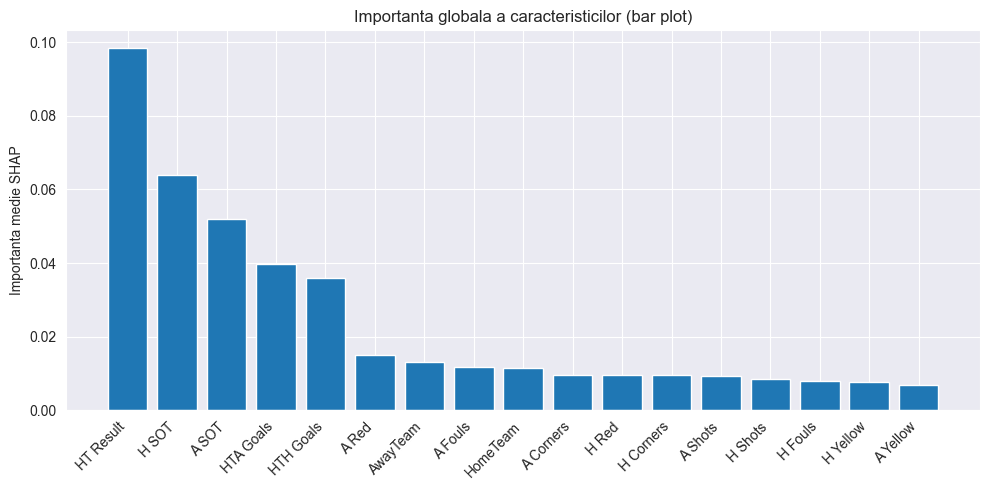

,feature,mean_abs_shap
4,HT Result,0.098337
7,H SOT,0.063947
8,A SOT,0.051924
3,HTA Goals,0.039631
2,HTH Goals,0.036015
16,A Red,0.014919
1,AwayTeam,0.013074
10,A Fouls,0.011807
0,HomeTeam,0.011461
12,A Corners,0.009625


In [117]:
global_importance = np.mean(np.abs(shap_values_array), axis=(0, 1))  # (n_features,)
global_importance_df = pd.DataFrame({
    'feature': feature_cols,
    'mean_abs_shap': global_importance
}).sort_values(by='mean_abs_shap', ascending=False)

plt.figure(figsize=(10, 5))
plt.bar(global_importance_df['feature'], global_importance_df['mean_abs_shap'])
plt.xticks(rotation=45, ha='right')
plt.ylabel('Importanta medie SHAP')
plt.title('Importanta globala a caracteristicilor (bar plot)')
plt.tight_layout()
plt.show()

global_importance_df


Cum era de asteptat, influenteaza foarte mult rezultatul de la pauza. Totodata, numarul de suturi pe poarta a ambelor echipe este un factor important in clasificare, chiar mai important decat numarul de goluri de la pauza, ceea ce este foarte interesant.
In plus, conteaza si tipul de echipa : gazda sau oaspete.

Pentru summary plot, vom alege o singura clasa pe rand ca sa generam graficul.

1. Pentru rezultatul de victorie gazda

C:\Users\Razvan\AppData\Local\Temp\ipykernel_7540\2895687492.py:3: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


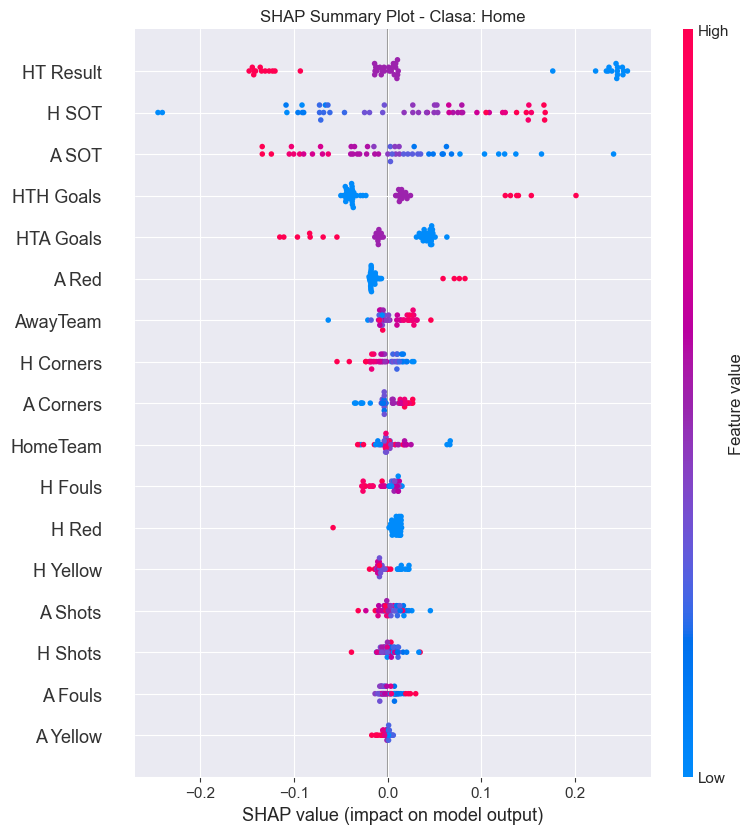

In [118]:
clasa_vizualizata = 0
plt.figure(figsize=(10, 6))
shap.summary_plot(
    shap_values_array[clasa_vizualizata],
    X_shap_sample,
    feature_names = feature_cols,
    show=False
)
plt.title(f"SHAP Summary Plot - Clasa: {class_names[clasa_vizualizata]}")
plt.show()

Rezultatul de la pauza influenteaza valoarea SHAP in mod negativ mult mai mult decat in mod pozitiv. Suturile pe spatiul portii a echipei gazda trage valoarea shap in sus, in timp ce numaru de suturi a echipei oaspete rage in jos, total normal, deoarece privim din perspectiva rezultatului de victorie pentru echipa gazda.

2. Pentru rezultatul de egalitate:

C:\Users\Razvan\AppData\Local\Temp\ipykernel_7540\1000785087.py:3: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


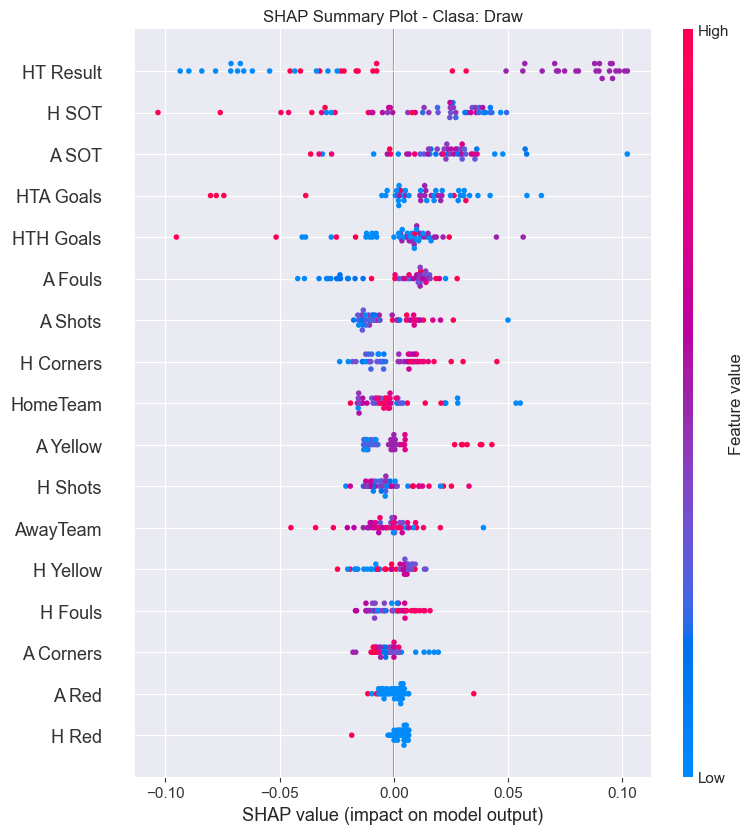

In [119]:
clasa_vizualizata = 1
plt.figure(figsize=(10, 6))
shap.summary_plot(
    shap_values_array[clasa_vizualizata],
    X_shap_sample,
    feature_names = feature_cols,
    show=False
)
plt.title(f"SHAP Summary Plot - Clasa: {class_names[clasa_vizualizata]}")
plt.show()

In urma acestui grafic, surprinzator putem spune ca a 3-a influenta pentru rezultatul de egalitate o are numarul de fault-uri a echipei ce joaca in deplasare. Multe atribute tind sa traga putin in sus valoarea shap.

3. Pentru rezultatul de victorie a oaspetilor:

C:\Users\Razvan\AppData\Local\Temp\ipykernel_7540\1188454187.py:3: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


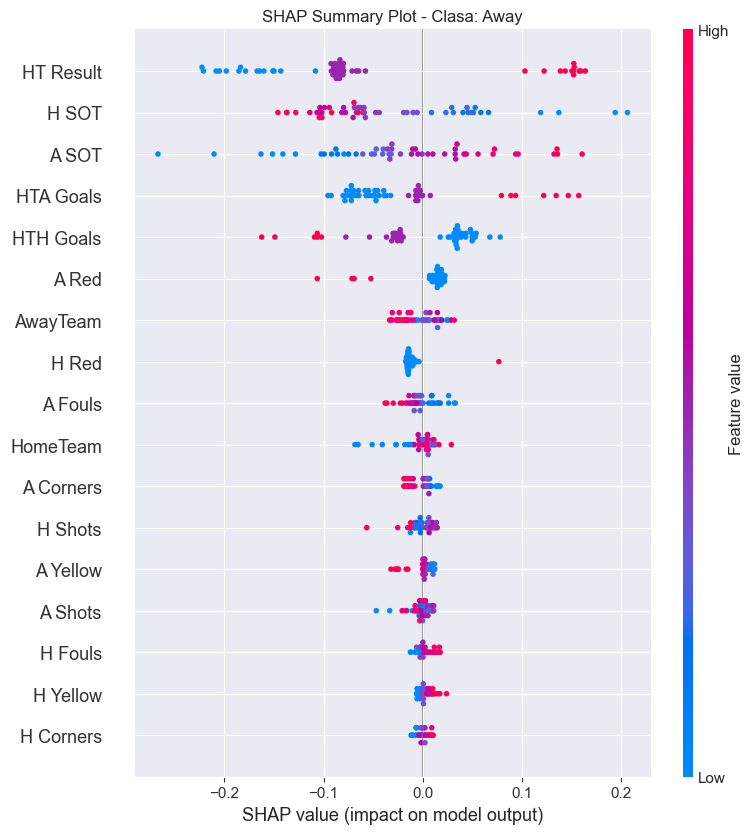

In [120]:
clasa_vizualizata = 2
plt.figure(figsize=(10, 6))
shap.summary_plot(
    shap_values_array[clasa_vizualizata],
    X_shap_sample,
    feature_names = feature_cols,
    show=False
)
plt.title(f"SHAP Summary Plot - Clasa: {class_names[clasa_vizualizata]}")
plt.show()

Practiv e invers rezultatului de castig a echipei gazda.

#### Explicație locală
Aceasta analiza ne arata cum se comporta modelul in cadrul unei predictii:

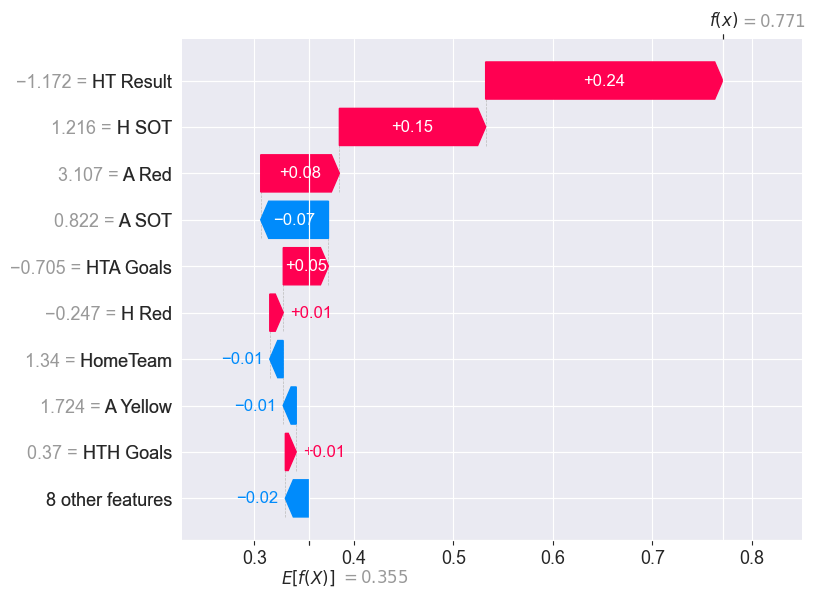

In [121]:
X_df = pd.DataFrame(X_shap_sample, columns=X_train.columns)
explanation_obj = explainer(X_df)
shap.plots.waterfall(explanation_obj[0, :, 0])

In graficul de tip waterfall de mai sus putem observa cele mai influente atribute in cazul predictiei pentru victoria gazdelor.
Valoarea de baza reprezinta media tuturor, catre care tinde predictia pentru aceasta clasa, fiind de 0.3 aproximativ.
Ce este in dreapta, sus, in cazul nostru 2.556 reprezinta suma dintre media valoarea de baza si valorile shap din stanga, fiind predictia finala.
Putem observa ca mai multe atribute au o influenta negativa, dar mai mica, fata de cele care trag in sus valoarea shap.

In [122]:
shap.initjs()
shap.plots.force(explanation_obj[0, :, 0])

Force plot are aceeasi semnificatie cu graficul de tipul waterfall. Se pastreaza consistent culoarea atributelor, cele colorate in albastru 'slabesc' modelul, iar culoarea rosie il ajuta sa prezica un rezultat mai bun.

#### Scatter plot
O sa facem scatter plot pentru urmatoarele features:
- HT Result
- H SOT
- AwayTeam

Altfel spus, dorim sa vedem cu adevarat valorile acestor atribute si cat de mult influenteaza individual.

Scatter plot pentru H2H:

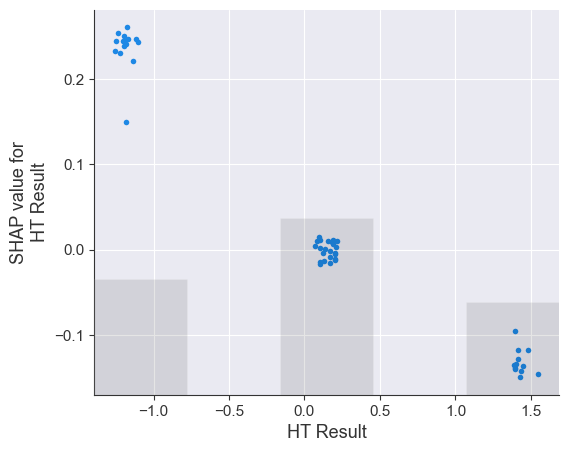

In [123]:
h2h_index = list(X_train.columns).index("HT Result")
shap.plots.scatter(explanation_obj[:, h2h_index, 0])

Mai sus putem vedea clasele pentru clasificare, grupate in 3:
- Victorie Gazde
- Egal
- Victorie Oaspeti

Scatter plot pentru _diferenta de forma_:

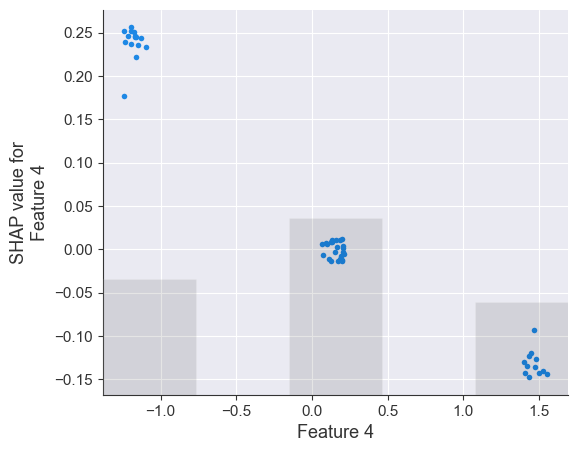

In [124]:
ht_result_index = list(X_train.columns).index('HT Result')
shap.plots.scatter(shap_explanation[:, ht_result_index, 0])


Mai sus este reprezentata diferenta de forma. Putem observa ca acest atribut nu prea conteaza, deoarece aceasta diferenta este mica, multe in intervalul [-1,1]. Din aceasta observatie rezulta ca toate echipele sunt echilibrate ca forma si valoarea shap este aproximativ situata in intervalul [-0.2, 0.2].

Scatter plot pentru echipa gazda:


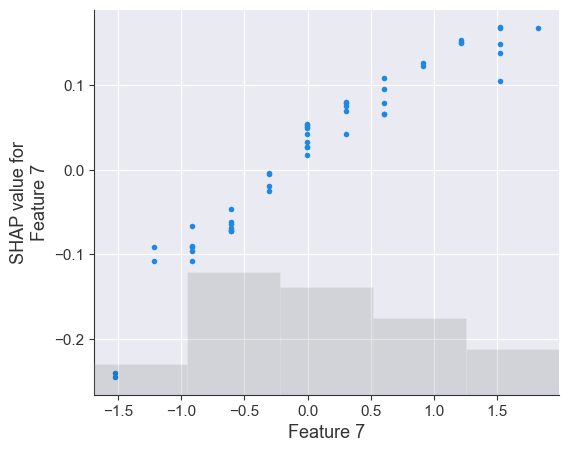

In [125]:
h_sot_index = list(X_train.columns).index('H SOT')
shap.plots.scatter(shap_explanation[:, h_sot_index, 0])


In graficul de mai sus, este subliniata importanta terenului propriu. Id-ul echipei este si negativ datorata faptului ca am folosit scalarea, deoarece nu am dorit ca un id mare sa influenteze mai mult.
Valuarea shap este stabilizata in jurul valorii de 0.

#### Cele mai bune predictii conform analizei shap sunt :
- H2H_Score (din graficul waterfall).
- Diff_Conceded
- Diff_Form

Pentru un exemplu concret din clasa 0 : castiga gazdele.
- valoarea de baza este 0.354. Predictia este impinsa pozitiv datorita lui H2H_score si diff_conceded. Rezulta faptul ca meciurile directe si diferenta dintre nr. de goluri primite conteaza.
- Pe partea negativa, au influentat A_Points_Avg si Diff_Score.

### 2. Support Vector Machine Optimizat - SHAP

Ca si explainer vom folosi un _KernelExplainer_, fiind mai performant si cu un numar mic de exemple din cauza timpului de executie.

In [126]:
background_size =min(30, len(X_train_scaled))
best_svm.fit(X_train_scaled, y_train)
background = pd.DataFrame(X_train_scaled).sample(background_size, random_state=10)
explainer = shap.KernelExplainer(best_svm.predict_proba, background)

Calculez valori shap pentru exemple din setul de date:

In [127]:
sample_size =min(10, len(X_test_scaled))
X_shap_sample = X_test_scaled[:sample_size].copy()

shap_values =explainer.shap_values(X_shap_sample)
expected_values =explainer.expected_value

print("Număr exemple explicate:", len(X_shap_sample))
print("Tip obiect shap_values:", type(shap_values))

  0%|          | 0/10 [00:00<?, ?it/s]

Număr exemple explicate: 10
Tip obiect shap_values: <class 'numpy.ndarray'>


In [128]:
class_names = ['Home', 'Drow', 'Away']
if isinstance(shap_values, list):
    shap_values_array = np.array(shap_values)
else:
    shap_values_array = np.array(shap_values)
    if shap_values_array.ndim == 3:
        # posibil format: (n_samples, n_features, n_classes)
        if shap_values_array.shape[0] == len(X_shap_sample) and shap_values_array.shape[2] == len(class_names):
            shap_values_array = np.transpose(shap_values_array, (2, 0, 1))
    elif shap_values_array.ndim == 2:
        shap_values_array = shap_values_array[np.newaxis, :, :]

print("Forma shap_values_array:", shap_values_array.shape)

Forma shap_values_array: (3, 10, 17)


#### Interpretare globala :
Observam importanta medie absoluta la toate caracteristicile.

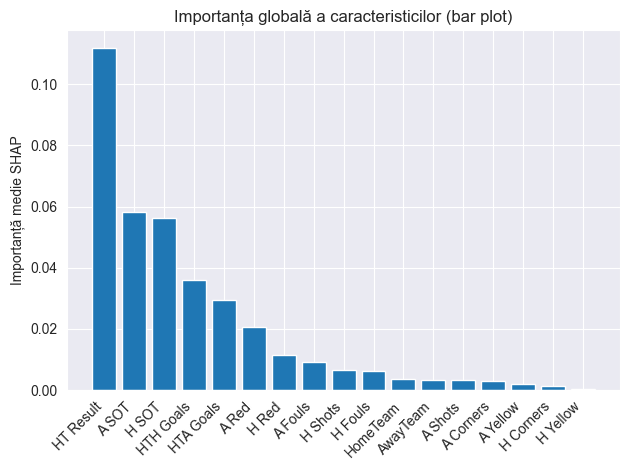

,feature,mean_abs_shap
4,HT Result,0.112009
8,A SOT,0.058402
7,H SOT,0.056166
2,HTH Goals,0.035944
3,HTA Goals,0.029597
16,A Red,0.020534
15,H Red,0.011579
10,A Fouls,0.009213
5,H Shots,0.006756
9,H Fouls,0.006174


In [129]:
global_importance = np.mean(np.abs(shap_values_array), axis=(0, 1))
feature_cols = X.columns.tolist()
global_importance_df = pd.DataFrame({
    "feature": feature_cols,
    "mean_abs_shap": global_importance
}).sort_values(by="mean_abs_shap", ascending=False)

plt.figure()
plt.bar(global_importance_df["feature"], global_importance_df["mean_abs_shap"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("Importanță medie SHAP")
plt.title("Importanța globală a caracteristicilor (bar plot)")
plt.tight_layout()
plt.show()

global_importance_df

Ca si importanta globala, se observa ca HT Result este cu cea mai mare influenta, urmata de suturile pe spatiul portii si numarul de goluri de la pauza.

Pentru summary plot, vom alege o singura clasa pe rand ca sa generam graficul.


1. Pentru rezultatul de victorie gazda

C:\Users\Razvan\AppData\Local\Temp\ipykernel_7540\2895687492.py:3: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


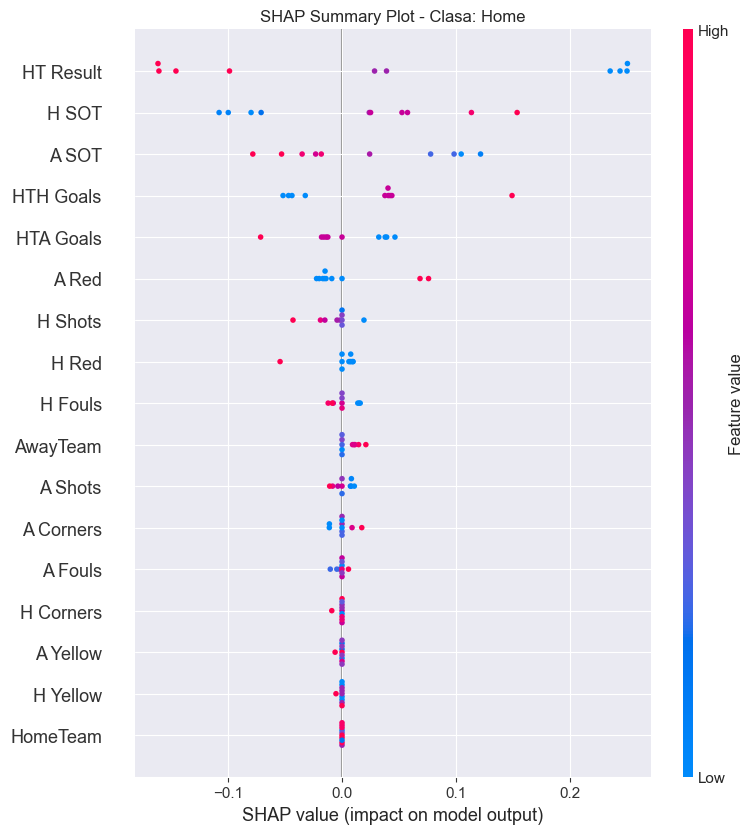

In [130]:
clasa_vizualizata = 0
plt.figure(figsize=(10, 6))
shap.summary_plot(
    shap_values_array[clasa_vizualizata],
    X_shap_sample,
    feature_names = feature_cols,
    show=False
)
plt.title(f"SHAP Summary Plot - Clasa: {class_names[clasa_vizualizata]}")
plt.show()

2. Pentru rezultatul de victorie gazda

C:\Users\Razvan\AppData\Local\Temp\ipykernel_7540\1000785087.py:3: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


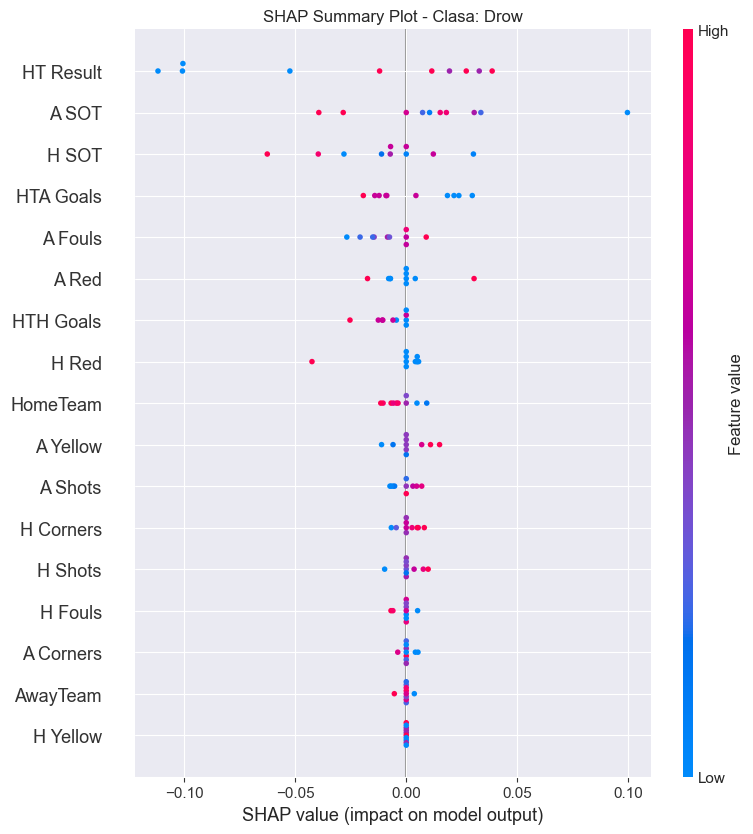

In [131]:
clasa_vizualizata = 1
plt.figure(figsize=(10, 6))
shap.summary_plot(
    shap_values_array[clasa_vizualizata],
    X_shap_sample,
    feature_names = feature_cols,
    show=False
)
plt.title(f"SHAP Summary Plot - Clasa: {class_names[clasa_vizualizata]}")
plt.show()

3. Pentru rezultatele de victorie a echipei oaspete

C:\Users\Razvan\AppData\Local\Temp\ipykernel_7540\1188454187.py:3: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


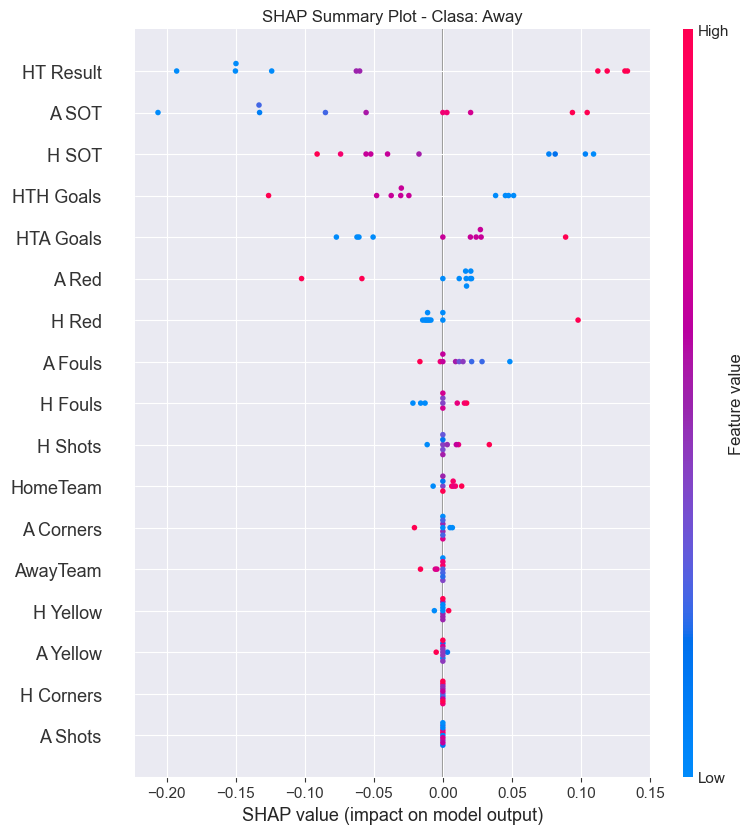

In [132]:
clasa_vizualizata = 2
plt.figure(figsize=(10, 6))
shap.summary_plot(
    shap_values_array[clasa_vizualizata],
    X_shap_sample,
    feature_names = feature_cols,
    show=False
)
plt.title(f"SHAP Summary Plot - Clasa: {class_names[clasa_vizualizata]}")
plt.show()

In urma analizei pentru fiecare clasa in parte rezulta urmatoarele:
- HT Result este cea mai importanta caracteristica, care este impartita in parte pozitiva si negativa.
- Urmata de numarul de suturi pe spatiul portii si numarul de goluri de la pauza.

#### Explicație locală
Aceasta analiza ne arata cum se comporta modelul in cadrul unei predictii:

  0%|          | 0/10 [00:00<?, ?it/s]

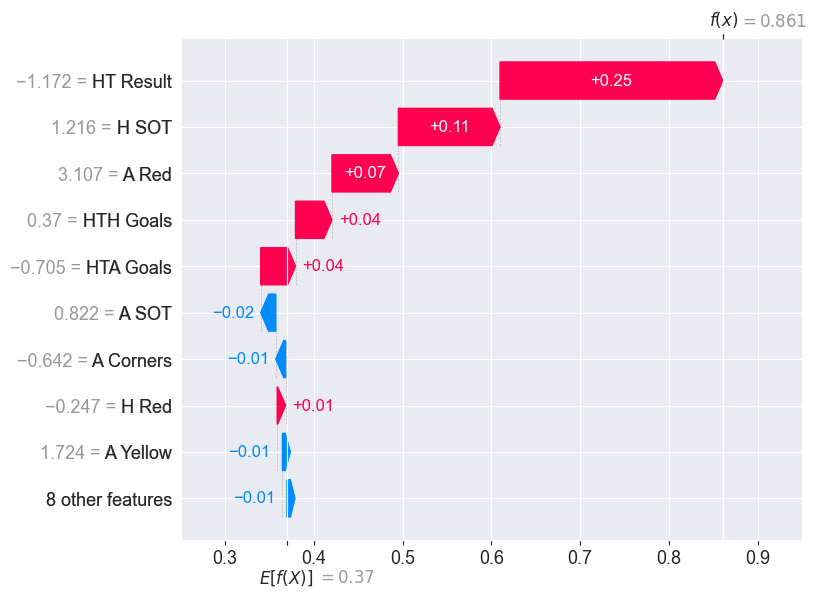

In [133]:
X_df = pd.DataFrame(X_shap_sample, columns=X_train.columns)
explanation_obj = explainer(X_df)
shap.plots.waterfall(explanation_obj[0, :, 0])

In diagrama waterfall se observa urmatoarele :
- valoarea de baza este de 0.37.
- predictia finala este de 0.861.
- Valoarea shap este trasa in sus mult mai mult decat in jos de catre atribute.

In [134]:
shap.initjs()
shap.plots.force(explanation_obj[0, :, 0])

Pentru partea de analiza a 3 caracteristici, am luat in considerare sa iau aceleasi la toate modelele. In plus,consider ca urmatoarele rezultate si rezultatele anterioare de la analiza globala sunt influentate si de numarul de exemple rulate de model.

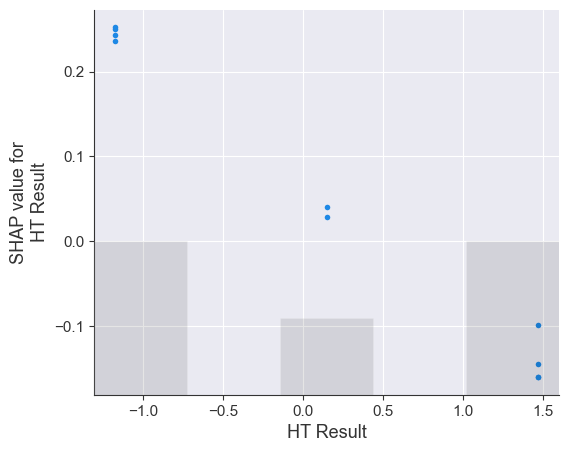

In [135]:
h2h_index = list(X_train.columns).index("HT Result")
shap.plots.scatter(explanation_obj[:, h2h_index, 0])

Atributul de H2H influenteaza valoarea H2H mai mult in partea pozitiva.

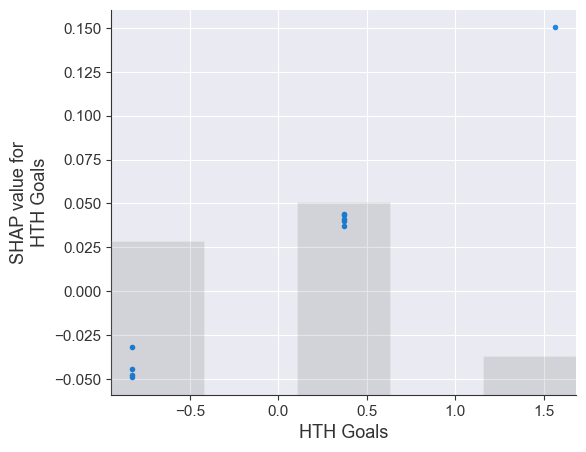

In [136]:
diff_form_index = list(X_train.columns).index("HTH Goals")
shap.plots.scatter(explanation_obj[:, diff_form_index, 0])

Atributul de H2H influenteaza valoarea Diff_form mai mult in partea pozitiva.

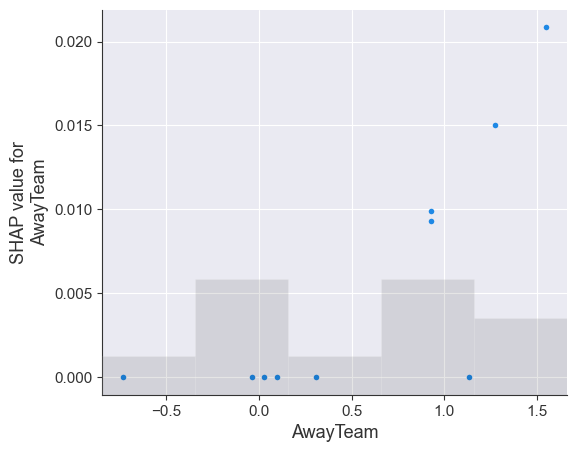

In [137]:
home_team_index = list(X_train.columns).index("AwayTeam")
shap.plots.scatter(explanation_obj[:, home_team_index, 0])

Interesant pentru _AwayTeam_ este faptul ca nu impinge in jos deloc, ceea ce se putea vedea din diagrama waterfall.

### 3.Logistic Regression Optimizat - SHAP

Ca si explainer vom folosi un _LinearExplainer_, fiind mai performant.

In [138]:
background_size =min(30, len(X_train_scaled))
best_log.fit(X_train_scaled, y_train)
background = pd.DataFrame(X_train_scaled).sample(background_size, random_state=10)
explainer = shap.LinearExplainer(best_log,X_train_scaled)

C:\Facultate\An_3\Semestrul_2\SI\Lab\proiect-ml-RazvanBarna\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


In [139]:
sample_size =min(500, len(X_test_scaled))
X_shap_sample = X_test_scaled[:sample_size].copy()

shap_values =explainer.shap_values(X_shap_sample)
expected_values =explainer.expected_value

print("Număr exemple explicate:", len(X_shap_sample))
print("Tip obiect shap_values:", type(shap_values))

Număr exemple explicate: 500
Tip obiect shap_values: <class 'numpy.ndarray'>


In [140]:
class_names = ['Home', 'Drow', 'Away']
if isinstance(shap_values, list):
    shap_values_array = np.array(shap_values)
else:
    shap_values_array = np.array(shap_values)
    if shap_values_array.ndim == 3:
        # posibil format: (n_samples, n_features, n_classes)
        if shap_values_array.shape[0] == len(X_shap_sample) and shap_values_array.shape[2] == len(class_names):
            shap_values_array = np.transpose(shap_values_array, (2, 0, 1))
    elif shap_values_array.ndim == 2:
        shap_values_array = shap_values_array[np.newaxis, :, :]

print("Forma shap_values_array:", shap_values_array.shape)

Forma shap_values_array: (3, 500, 17)


#### Interpretare globala :
Observam importanta medie absoluta la toate caracteristicile.

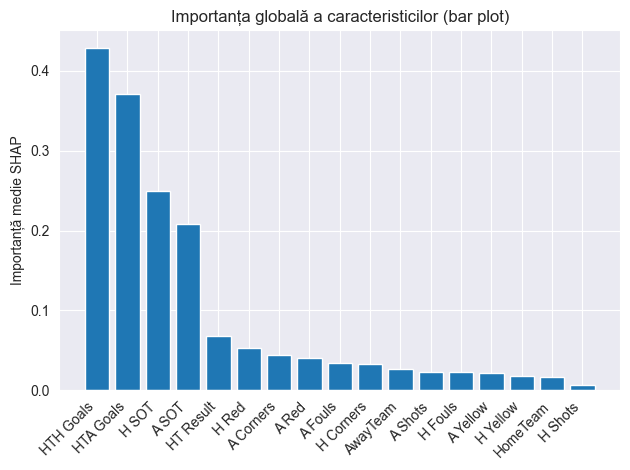

,feature,mean_abs_shap
2,HTH Goals,0.429212
3,HTA Goals,0.371125
7,H SOT,0.249594
8,A SOT,0.208658
4,HT Result,0.068129
15,H Red,0.052220
12,A Corners,0.043518
16,A Red,0.040479
10,A Fouls,0.034640
11,H Corners,0.032523


In [141]:
global_importance = np.mean(np.abs(shap_values_array), axis=(0, 1))
feature_cols = X.columns.tolist()
global_importance_df = pd.DataFrame({
    "feature": feature_cols,
    "mean_abs_shap": global_importance
}).sort_values(by="mean_abs_shap", ascending=False)

plt.figure()
plt.bar(global_importance_df["feature"], global_importance_df["mean_abs_shap"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("Importanță medie SHAP")
plt.title("Importanța globală a caracteristicilor (bar plot)")
plt.tight_layout()
plt.show()

global_importance_df

Interesant este faptul ca pentru Logistic Regression, cea mai mare influenta o au numarul de goluri de la pauza si numarul de suturi pe spatiul portii de la ambele echipe.

Pentru summary plot, vom alege o singura clasa pe rand ca sa generam graficul.


1. Pentru rezultatul de victorie gazda

C:\Users\Razvan\AppData\Local\Temp\ipykernel_7540\2895687492.py:3: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


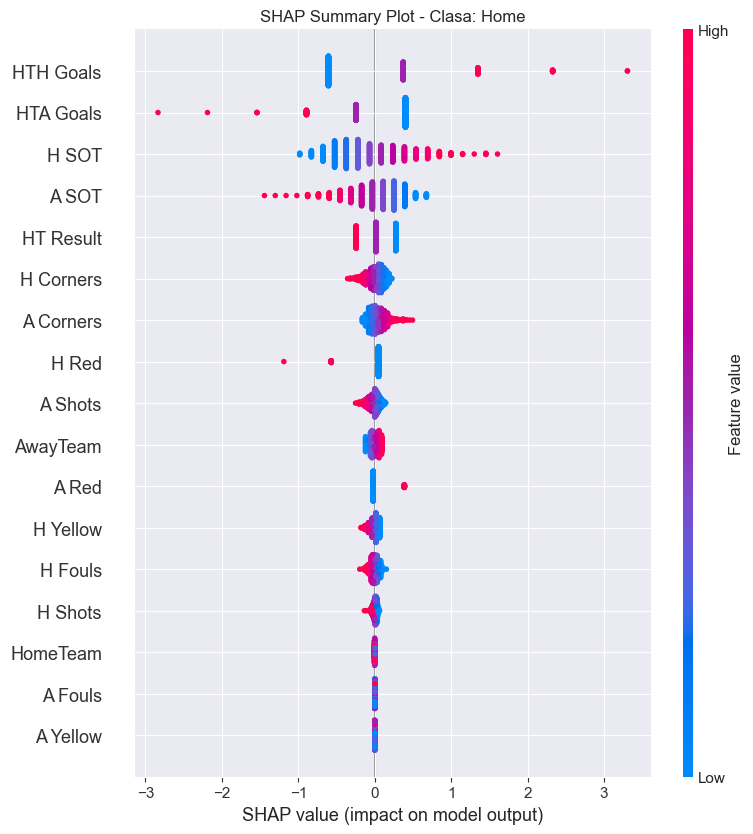

In [142]:
clasa_vizualizata = 0
plt.figure(figsize=(10, 6))
shap.summary_plot(
    shap_values_array[clasa_vizualizata],
    X_shap_sample,
    feature_names = feature_cols,
    show=False
)
plt.title(f"SHAP Summary Plot - Clasa: {class_names[clasa_vizualizata]}")
plt.show()

Numarul de goluri influenteaza pozitiv pentru echipa gazda si invers pentru cealalta echipa, deoarece privim din perspectiva echipei ce joaca acasa. Datele sunt simetrice si la suturi.

2. Pentru rezultatul de egalitate

C:\Users\Razvan\AppData\Local\Temp\ipykernel_7540\1000785087.py:3: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


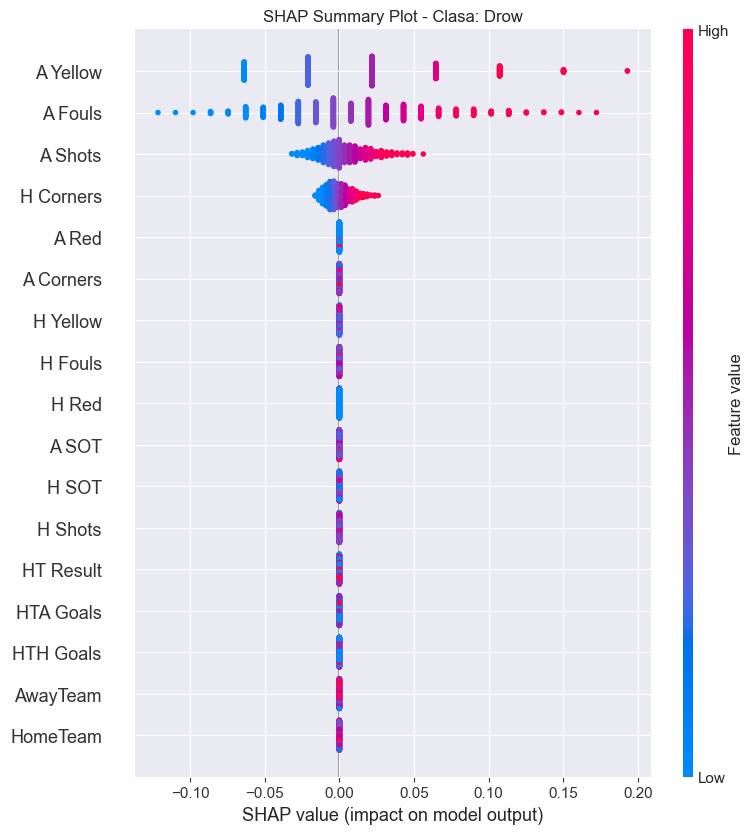

In [143]:
clasa_vizualizata = 1
plt.figure(figsize=(10, 6))
shap.summary_plot(
    shap_values_array[clasa_vizualizata],
    X_shap_sample,
    feature_names = feature_cols,
    show=False
)
plt.title(f"SHAP Summary Plot - Clasa: {class_names[clasa_vizualizata]}")
plt.show()

In cazul rezultatului de egalitate, influentele sunt echilibrate, dar ting sa traga in sus valoarea shap cu putin, nu-si poate da seama foarte bine de rezultat.

3. Pentru rezultatul de victorie a oaspetilor

C:\Users\Razvan\AppData\Local\Temp\ipykernel_7540\1188454187.py:3: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


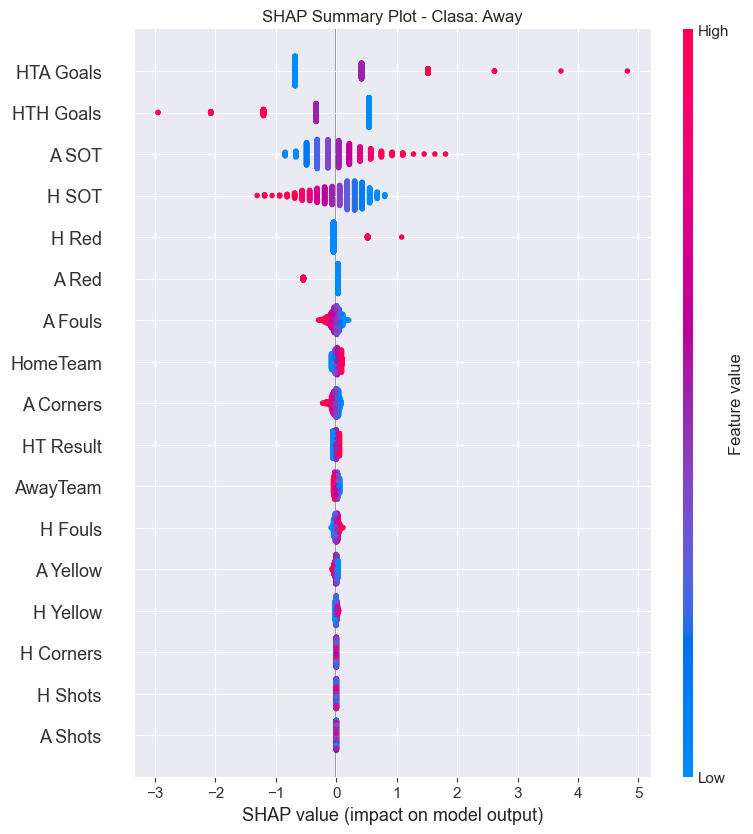

In [144]:
clasa_vizualizata = 2
plt.figure(figsize=(10, 6))
shap.summary_plot(
    shap_values_array[clasa_vizualizata],
    X_shap_sample,
    feature_names = feature_cols,
    show=False
)
plt.title(f"SHAP Summary Plot - Clasa: {class_names[clasa_vizualizata]}")
plt.show()

Invers fata de rezultatul de victorie pentru gazda.

#### Explicație locală
Aceasta analiza ne arata cum se comporta modelul in cadrul unei predictii:

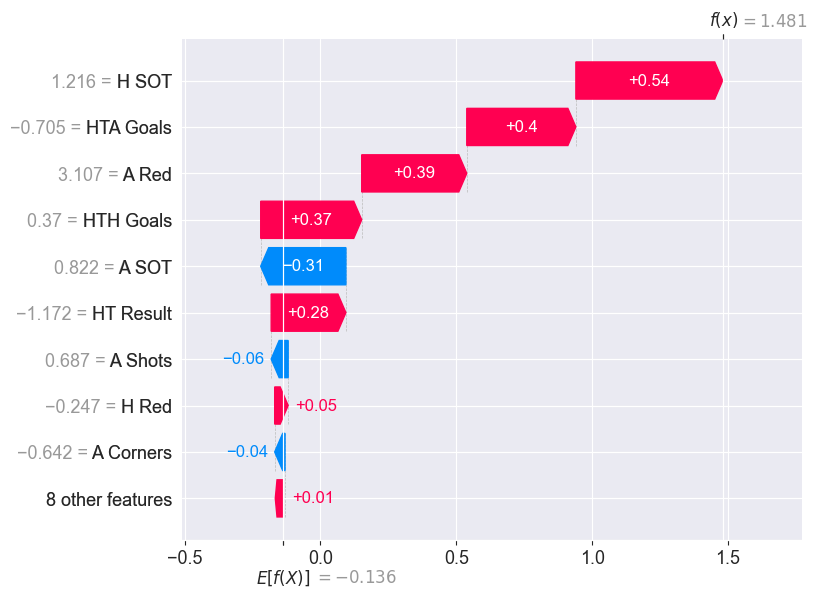

In [145]:
X_df = pd.DataFrame(X_shap_sample, columns=X_train.columns)
explanation_obj = explainer(X_df)
shap.plots.waterfall(explanation_obj[0, :, 0])

In diagrama waterfall se observa urmatoarele :
- valoarea de baza este de -0.136.
- predictia finala este de 1.481.
- Modelul este putin tras in jos, in principiu de toate actiune ofensive a echipei din deplasare.

In [146]:
shap.initjs()
shap.plots.force(explanation_obj[0, :, 0])

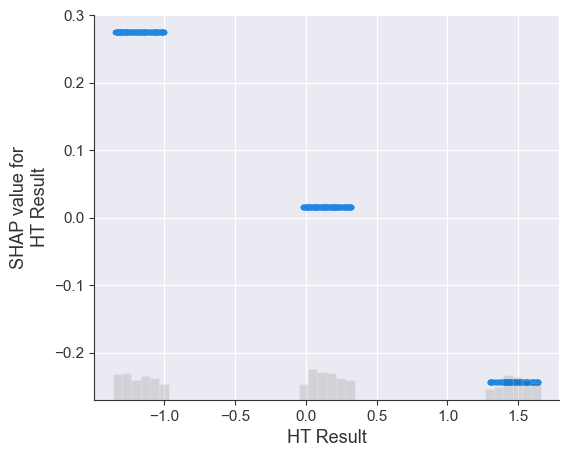

In [147]:
h2h_index = list(X_train.columns).index("HT Result")
shap.plots.scatter(explanation_obj[:, h2h_index, 0])

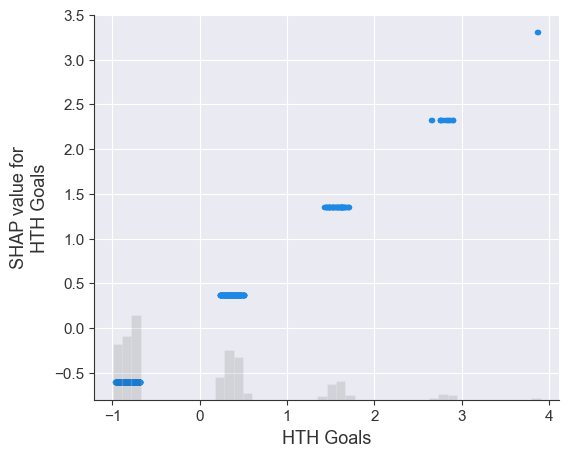

In [148]:
diff_form_index = list(X_train.columns).index("HTH Goals")
shap.plots.scatter(explanation_obj[:, diff_form_index, 0])

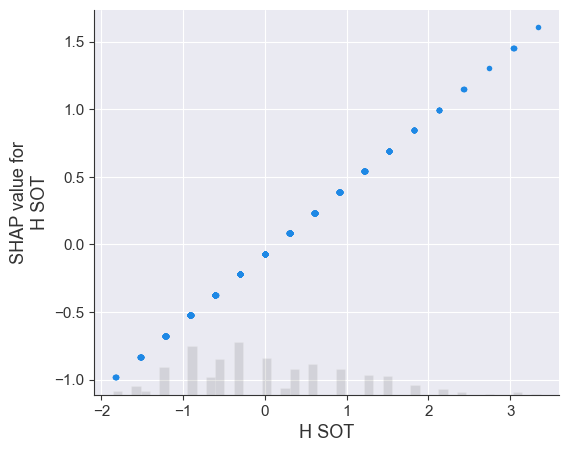

In [149]:
home_team_index = list(X_train.columns).index("H SOT")
shap.plots.scatter(explanation_obj[:, home_team_index, 0])

De remarcat liniaritatea perfecta pe care o are numarul de suturi pe spatiul portii cu valoarea shap.

#### Cele mai bune caracteristici conform analizei shap sunt :
- HT Result
- Numarul de suturi pe spatiul portii
- Numarul de suturi per total

Pentru un exemplu concret din clasa 0 : castiga gazdele.
- valoarea de baza este -0.1. Predictia este impinsa pozitiv datorita lui HTH Goals si H SOT. Rezulta faptul ca meciurile directe si cine e echipa gazda conteaza.
- Pe partea negativa, valorile Shap sunt impinse in jos cel mai mult de caracteristica: A SOT, echipa adversa.

In [152]:
import joblib
joblib.dump(svm_base, '../Models/Classification/base_svm.pkl')
joblib.dump(cat_base, '../Models/Classification/base_cat.pkl')
joblib.dump(ebm_base, '../Models/Classification/base_ebm.pkl')
joblib.dump(log_base, '../Models/Classification/base_log.pkl')
joblib.dump(rf_base, '../Models/Classification/base_rf.pkl')

joblib.dump(best_log, '../Models/Classification/best_log.pkl')
joblib.dump(best_ebm, '../Models/Classification/best_ebm.pkl')
joblib.dump(best_catB, '../Models/Classification/best_cat.pkl')
joblib.dump(best_rf, '../Models/Classification/best_rf.pkl')
joblib.dump(best_svm, '../Models/Classification/best_svm.pkl')



['../Models/Classification/best_svm.pkl']

In [202]:
joblib.dump(svm_base, '../Models/Classification/base_svm.pkl')
joblib.dump(cat_base, '../Models/Classification/base_cat.pkl')
joblib.dump(ebm_base, '../Models/Classification/base_ebm.pkl')
joblib.dump(log_base, '../Models/Classification/base_log.pkl')
joblib.dump(rf_base, '../Models/Classification/base_rf.pkl')

['../Models/Classification/base_rf.pkl']